In [1]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
#from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from statsmodels.graphics.mosaicplot import mosaic
import matplotlib.ticker as ticker
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import classification_report, confusion_matrix
import lightgbm as lgb
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight
from itertools import product
from sklearn.naive_bayes import GaussianNB
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import StandardScaler
from xgboost import plot_importance
import shap
from sklearn.metrics import precision_score, recall_score, f1_score

c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
#### Activar segun quien trabaje 
#Marco
Filepath = "C:/Users/user/OneDrive/Documentos/semestres uniandes/Clases 2025-1/Tesis IIND/Solo sector salud/Base analisis exploratorio.csv"
#Paula
#Filepath= "C:/Users/paula/OneDrive/Documentos/10 Semestre/Tesis/base con categorias reducidas2.csv"
df=pd.read_csv(Filepath)
df.drop(columns=['nombre entidad'], inplace=True)
df

,nit entidad,departamento,ciudad,orden,rama,entidad centralizada,estado contrato,codigo de categoria principal,tipo de contrato,modalidad de contratacion,...,fase,precio base,nombre de la unidad de contratación,departamento proveedor,ciudad proveedor,tiempo duracion (dias),duracion_proceso_dias,año_publicacion,porcentaje_pagado,Adicion
0,Otros,Meta,Villavicencio,Territorial,Ejecutivo,Centralizada,En ejecución,V1.85101600,Prestación de servicios,Contratación régimen especial,...,Presentación de oferta,8.273630e+06,Otros,Meta,Otros,38.0,39.0,2024,25-50%,0
1,900959051,Distrito Capital de Bogotá,Bogotá,Territorial,Ejecutivo,Descentralizada,En ejecución,V1.80111600,Prestación de servicios,Contratación régimen especial,...,Presentación de oferta,2.908492e+07,CONTRATACION OPS 2020,Distrito Capital de Bogotá,Bogotá,48.0,53.0,2020,0-25%,1
2,890399011,Valle del Cauca,Cali,Territorial,Ejecutivo,Centralizada,En ejecución,V1.80111500,Prestación de servicios,Contratación directa,...,Presentación de oferta,5.907958e+07,SECRETARIA DISTRITAL DE SALUD DE CALI,Valle del Cauca,Cali,50.0,57.0,2020,0-25%,0
3,900971006,Distrito Capital de Bogotá,Bogotá,Territorial,Corporación Autónoma,Descentralizada,Activo,V1.85101600,Prestación de servicios,Contratación directa,...,Presentación de oferta,3.440880e+07,Otros,Distrito Capital de Bogotá,No Definido,88.0,90.0,2018,0-25%,1
4,891780185,Magdalena,Santa Marta,Territorial,Ejecutivo,Centralizada,En ejecución,Otros,Prestación de servicios,Contratación régimen especial,...,Presentación de oferta,7.000000e+07,Grupo de contratación SECOP II,Magdalena,Santa Marta,57.0,60.0,2022,0-25%,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
159178,Otros,Norte de Santander,Tibú,Territorial,Corporación Autónoma,Descentralizada,En ejecución,Otros,Decreto 092 de 2017,Contratación régimen especial,...,Presentación de oferta,1.427548e+08,Otros,Norte de Santander,Cúcuta,27.0,30.0,2023,75-100%,0
159179,891780185,Magdalena,Santa Marta,Territorial,Ejecutivo,Centralizada,En ejecución,V1.80111600,Prestación de servicios,Contratación régimen especial,...,Presentación de oferta,9.000000e+06,Grupo de contratación SECOP II,Magdalena,Santa Marta,145.0,150.0,2022,0-25%,0
159180,Otros,Casanare,Yopal,Territorial,Ejecutivo,Descentralizada,En ejecución,V1.80111701,Prestación de servicios,Contratación régimen especial,...,Presentación de oferta,1.800000e+06,Otros,Casanare,Otros,30.0,30.0,2023,0-25%,0
159181,899999239,Nariño,No Definido,Nacional,Ejecutivo,Centralizada,En ejecución,V1.80111600,Prestación de servicios,Contratación directa,...,Presentación de oferta,1.568828e+07,Otros,Nariño,Otros,175.0,173.0,2024,0-25%,0


In [4]:
# Convertir todas las columnas de tipo object a minúsculas
df = df.applymap(lambda x: x.lower() if isinstance(x, str) else x)
df

C:\Users\user\AppData\Local\Temp\ipykernel_1704\1824968316.py:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda x: x.lower() if isinstance(x, str) else x)


,nit entidad,departamento,ciudad,orden,rama,entidad centralizada,estado contrato,codigo de categoria principal,tipo de contrato,modalidad de contratacion,...,fase,precio base,nombre de la unidad de contratación,departamento proveedor,ciudad proveedor,tiempo duracion (dias),duracion_proceso_dias,año_publicacion,porcentaje_pagado,Adicion
0,otros,meta,villavicencio,territorial,ejecutivo,centralizada,en ejecución,v1.85101600,prestación de servicios,contratación régimen especial,...,presentación de oferta,8.273630e+06,otros,meta,otros,38.0,39.0,2024,25-50%,0
1,900959051,distrito capital de bogotá,bogotá,territorial,ejecutivo,descentralizada,en ejecución,v1.80111600,prestación de servicios,contratación régimen especial,...,presentación de oferta,2.908492e+07,contratacion ops 2020,distrito capital de bogotá,bogotá,48.0,53.0,2020,0-25%,1
2,890399011,valle del cauca,cali,territorial,ejecutivo,centralizada,en ejecución,v1.80111500,prestación de servicios,contratación directa,...,presentación de oferta,5.907958e+07,secretaria distrital de salud de cali,valle del cauca,cali,50.0,57.0,2020,0-25%,0
3,900971006,distrito capital de bogotá,bogotá,territorial,corporación autónoma,descentralizada,activo,v1.85101600,prestación de servicios,contratación directa,...,presentación de oferta,3.440880e+07,otros,distrito capital de bogotá,no definido,88.0,90.0,2018,0-25%,1
4,891780185,magdalena,santa marta,territorial,ejecutivo,centralizada,en ejecución,otros,prestación de servicios,contratación régimen especial,...,presentación de oferta,7.000000e+07,grupo de contratación secop ii,magdalena,santa marta,57.0,60.0,2022,0-25%,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
159178,otros,norte de santander,tibú,territorial,corporación autónoma,descentralizada,en ejecución,otros,decreto 092 de 2017,contratación régimen especial,...,presentación de oferta,1.427548e+08,otros,norte de santander,cúcuta,27.0,30.0,2023,75-100%,0
159179,891780185,magdalena,santa marta,territorial,ejecutivo,centralizada,en ejecución,v1.80111600,prestación de servicios,contratación régimen especial,...,presentación de oferta,9.000000e+06,grupo de contratación secop ii,magdalena,santa marta,145.0,150.0,2022,0-25%,0
159180,otros,casanare,yopal,territorial,ejecutivo,descentralizada,en ejecución,v1.80111701,prestación de servicios,contratación régimen especial,...,presentación de oferta,1.800000e+06,otros,casanare,otros,30.0,30.0,2023,0-25%,0
159181,899999239,nariño,no definido,nacional,ejecutivo,centralizada,en ejecución,v1.80111600,prestación de servicios,contratación directa,...,presentación de oferta,1.568828e+07,otros,nariño,otros,175.0,173.0,2024,0-25%,0


In [6]:
import unicodedata

# Función para eliminar tildes
def eliminar_tildes(s):
    if isinstance(s, str):
        return ''.join(c for c in unicodedata.normalize('NFD', s) if unicodedata.category(c) != 'Mn')
    return s

# Aplicar la función a todo el DataFrame
df = df.applymap(eliminar_tildes)
df

C:\Users\user\AppData\Local\Temp\ipykernel_1704\658783835.py:10: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(eliminar_tildes)


,nit entidad,departamento,ciudad,orden,rama,entidad centralizada,estado contrato,codigo de categoria principal,tipo de contrato,modalidad de contratacion,...,fase,precio base,nombre de la unidad de contratacion,departamento proveedor,ciudad proveedor,tiempo duracion (dias),duracion_proceso_dias,ano_publicacion,porcentaje_pagado,Adicion
0,otros,meta,villavicencio,territorial,ejecutivo,centralizada,en ejecucion,v1.85101600,prestacion de servicios,contratacion regimen especial,...,presentacion de oferta,8.273630e+06,otros,meta,otros,38.0,39.0,2024,25-50%,0
1,900959051,distrito capital de bogota,bogota,territorial,ejecutivo,descentralizada,en ejecucion,v1.80111600,prestacion de servicios,contratacion regimen especial,...,presentacion de oferta,2.908492e+07,contratacion ops 2020,distrito capital de bogota,bogota,48.0,53.0,2020,0-25%,1
2,890399011,valle del cauca,cali,territorial,ejecutivo,centralizada,en ejecucion,v1.80111500,prestacion de servicios,contratacion directa,...,presentacion de oferta,5.907958e+07,secretaria distrital de salud de cali,valle del cauca,cali,50.0,57.0,2020,0-25%,0
3,900971006,distrito capital de bogota,bogota,territorial,corporacion autonoma,descentralizada,activo,v1.85101600,prestacion de servicios,contratacion directa,...,presentacion de oferta,3.440880e+07,otros,distrito capital de bogota,no definido,88.0,90.0,2018,0-25%,1
4,891780185,magdalena,santa marta,territorial,ejecutivo,centralizada,en ejecucion,otros,prestacion de servicios,contratacion regimen especial,...,presentacion de oferta,7.000000e+07,grupo de contratacion secop ii,magdalena,santa marta,57.0,60.0,2022,0-25%,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
159178,otros,norte de santander,tibu,territorial,corporacion autonoma,descentralizada,en ejecucion,otros,decreto 092 de 2017,contratacion regimen especial,...,presentacion de oferta,1.427548e+08,otros,norte de santander,cucuta,27.0,30.0,2023,75-100%,0
159179,891780185,magdalena,santa marta,territorial,ejecutivo,centralizada,en ejecucion,v1.80111600,prestacion de servicios,contratacion regimen especial,...,presentacion de oferta,9.000000e+06,grupo de contratacion secop ii,magdalena,santa marta,145.0,150.0,2022,0-25%,0
159180,otros,casanare,yopal,territorial,ejecutivo,descentralizada,en ejecucion,v1.80111701,prestacion de servicios,contratacion regimen especial,...,presentacion de oferta,1.800000e+06,otros,casanare,otros,30.0,30.0,2023,0-25%,0
159181,899999239,narino,no definido,nacional,ejecutivo,centralizada,en ejecucion,v1.80111600,prestacion de servicios,contratacion directa,...,presentacion de oferta,1.568828e+07,otros,narino,otros,175.0,173.0,2024,0-25%,0


In [7]:
sinnombre = df.copy()
sinnombre.drop(columns=["Adicion"], inplace=True)
sinnombre.to_csv("C:/Users/user/OneDrive/Documentos/semestres uniandes/Clases 2025-1/Tesis IIND/Solo sector salud/Base analisis exploratorio sinnombre.csv", index=False)

In [8]:
df.columns

Index(['nit entidad', 'departamento', 'ciudad', 'orden', 'rama',
       'entidad centralizada', 'estado contrato',
       'codigo de categoria principal', 'tipo de contrato',
       'modalidad de contratacion', 'justificacion modalidad de contratacion',
       'condiciones de entrega', 'es pyme', 'liquidacion',
       'origen de los recursos', 'destino gasto', 'valor del contrato',
       'valor pendiente de pago', 'estado bpin', 'anno bpin',
       'el contrato puede ser prorrogado', 'fase', 'precio base',
       'nombre de la unidad de contratacion', 'departamento proveedor',
       'ciudad proveedor', 'tiempo duracion (dias)', 'duracion_proceso_dias',
       'ano_publicacion', 'porcentaje_pagado', 'Adicion'],
      dtype='object')

In [9]:
# Filtrar contratos con adición
contratos_adicionados = df[df['Adicion'] == 1]

# Calcular el promedio del valor del contrato
promedio_valor_contrato = contratos_adicionados['valor del contrato'].mean()

# Calcular el 20% del promedio
veinte_por_ciento = promedio_valor_contrato * 0.2

# Mostrar resultados
print(f"Promedio del valor del contrato: {promedio_valor_contrato}")
print(f"20% del promedio: {veinte_por_ciento}")

Promedio del valor del contrato: 36813561.24579481
20% del promedio: 7362712.249158963


In [10]:
#salario equipo revision
salario_equipo_revision_bajo =  3_107_410.69
salario_equipo_revision_medio =  5_340_558.54
salario_equipo_revision_alto =  8_581_298.43
print(f"Salario equipo revision bajo: {salario_equipo_revision_bajo}")
print(f"Salario equipo revision medio: {salario_equipo_revision_medio}")    
print(f"Salario equipo revision alto: {salario_equipo_revision_alto}") 



Salario equipo revision bajo: 3107410.69
Salario equipo revision medio: 5340558.54
Salario equipo revision alto: 8581298.43


In [11]:
# Obtener una fila donde 'Adicion' sea igual a 1
fila_adicion = df[df['Adicion'] == 1].iloc[2]
print(fila_adicion)

nit entidad                                                                   890399011
departamento                                                            valle del cauca
ciudad                                                                             cali
orden                                                                       territorial
rama                                                                          ejecutivo
entidad centralizada                                                       centralizada
estado contrato                                                            en ejecucion
codigo de categoria principal                                               v1.80111500
tipo de contrato                                                prestacion de servicios
modalidad de contratacion                                          contratacion directa
justificacion modalidad de contratacion    servicios profesionales y apoyo a la gestion
condiciones de entrega          

División de categoricas y númericas

In [12]:
# Seleccionar columnas categóricas, enteras y de punto flotante
catcols = df.select_dtypes(exclude=['int64', 'float64']).columns
intcols = df.select_dtypes(include=['int64']).columns
floatcols = df.select_dtypes(include=['float64']).columns



In [13]:
catcols

Index(['nit entidad', 'departamento', 'ciudad', 'orden', 'rama',
       'entidad centralizada', 'estado contrato',
       'codigo de categoria principal', 'tipo de contrato',
       'modalidad de contratacion', 'justificacion modalidad de contratacion',
       'condiciones de entrega', 'es pyme', 'liquidacion',
       'origen de los recursos', 'destino gasto', 'estado bpin', 'anno bpin',
       'el contrato puede ser prorrogado', 'fase',
       'nombre de la unidad de contratacion', 'departamento proveedor',
       'ciudad proveedor', 'porcentaje_pagado'],
      dtype='object')

In [14]:
# Contar el número de categorías únicas por cada variable categórica
category_counts = df[catcols].nunique()

# Mostrar los resultados
print("Número de categorías por variable categórica:")
print(category_counts)

Número de categorías por variable categórica:
nit entidad                                 12
departamento                                18
ciudad                                     169
orden                                        3
rama                                         3
entidad centralizada                         2
estado contrato                              2
codigo de categoria principal               12
tipo de contrato                             4
modalidad de contratacion                    6
justificacion modalidad de contratacion      5
condiciones de entrega                       5
es pyme                                      2
liquidacion                                  2
origen de los recursos                       2
destino gasto                                3
estado bpin                                  2
anno bpin                                    9
el contrato puede ser prorrogado             2
fase                                         2
nombre de la u

In [15]:
# Codificación de variables categóricas
df_dummies = pd.get_dummies(df, columns=catcols, dtype=int, drop_first=True)

# Identificar las categorías excluidas
excluded_categories = {}
for col in catcols:
    unique_values = df[col].unique()
    excluded_categories[col] = unique_values[0]  # La primera categoría es la excluida

# Mostrar las categorías excluidas
print("Categorías excluidas por multicolinealidad:")
for col, category in excluded_categories.items():
    print(f"{col}: {category}")

# Visualizar el DataFrame con variables dummies
df_dummies


Categorías excluidas por multicolinealidad:
nit entidad: otros
departamento: meta
ciudad: villavicencio
orden: territorial
rama: ejecutivo
entidad centralizada: centralizada
estado contrato: en ejecucion
codigo de categoria principal: v1.85101600
tipo de contrato: prestacion de servicios
modalidad de contratacion: contratacion regimen especial
justificacion modalidad de contratacion: regla aplicable
condiciones de entrega: a convenir
es pyme: no
liquidacion: no
origen de los recursos: recursos propios
destino gasto: funcionamiento
estado bpin: no valido
anno bpin: no d
el contrato puede ser prorrogado: no
fase: presentacion de oferta
nombre de la unidad de contratacion: otros
departamento proveedor: meta
ciudad proveedor: otros
porcentaje_pagado: 25-50%


,valor del contrato,valor pendiente de pago,precio base,tiempo duracion (dias),duracion_proceso_dias,ano_publicacion,Adicion,nit entidad_890399011,nit entidad_891780185,nit entidad_899999114,...,ciudad proveedor_manizales,ciudad proveedor_medellin,ciudad proveedor_no definido,ciudad proveedor_otros,ciudad proveedor_santa marta,ciudad proveedor_soacha,ciudad proveedor_villavicencio,porcentaje_pagado_25-50%,porcentaje_pagado_50-75%,porcentaje_pagado_75-100%
0,8273630.0,4136815.0,8.273630e+06,38.0,39.0,2024,0,0,0,0,...,0,0,0,1,0,0,0,1,0,0
1,5272122.0,5272122.0,2.908492e+07,48.0,53.0,2020,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,8439940.0,8439940.0,5.907958e+07,50.0,57.0,2020,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
3,34408800.0,34408800.0,3.440880e+07,88.0,90.0,2018,1,0,0,0,...,0,0,1,0,0,0,0,0,0,0
4,70000000.0,70000000.0,7.000000e+07,57.0,60.0,2022,0,0,1,0,...,0,0,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
159178,142754780.0,0.0,1.427548e+08,27.0,30.0,2023,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
159179,9000000.0,9000000.0,9.000000e+06,145.0,150.0,2022,0,0,1,0,...,0,0,0,0,1,0,0,0,0,0
159180,1800000.0,1800000.0,1.800000e+06,30.0,30.0,2023,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
159181,15688277.0,15688277.0,1.568828e+07,175.0,173.0,2024,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0


In [16]:
pruebaexcel=df.head(1000)
pruebaexcel.drop(columns=['Adicion'], inplace=True)
pruebaexcel.to_excel("prueba excel carga.xlsx", index=False)

C:\Users\user\AppData\Local\Temp\ipykernel_1704\1815170125.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pruebaexcel.drop(columns=['Adicion'], inplace=True)


In [17]:
muestradummies = df_dummies.head(1000)
muestradummies.drop(columns=['Adicion'], inplace=True) # Eliminar la columna 'Adicion' del DataFrame de muestra
muestradummies.to_csv("C:/Users/user/OneDrive/Documentos/semestres uniandes/Clases 2025-1/Tesis IIND/Solo sector salud/muestra dummies2.csv", index=False)

C:\Users\user\AppData\Local\Temp\ipykernel_1704\2067658503.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  muestradummies.drop(columns=['Adicion'], inplace=True) # Eliminar la columna 'Adicion' del DataFrame de muestra


In [18]:
# Definir las características (X) y la variable objetivo (y)
X = df_dummies.drop('Adicion', axis=1)  # 'Adicion' es la variable objetivo
y = df_dummies['Adicion']



In [19]:
# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [20]:
X_train = X_train.dropna()
y_train = y_train.loc[X_train.index]

X_test = X_test.dropna()
y_test = y_test.loc[X_test.index]


## XGBoost

### Salario medio

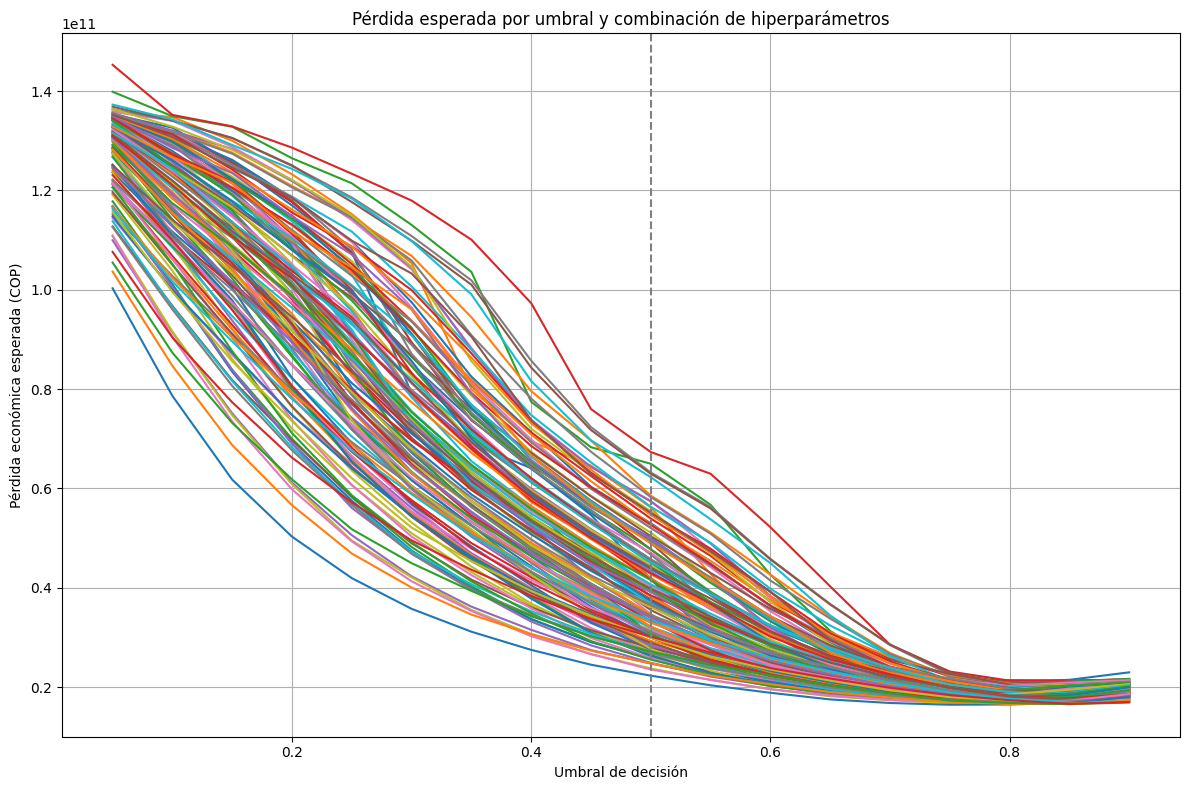

In [24]:
# Hiperparámetros a combinar (ya sin subsample ni colsample_bytree)
max_depths = [4, 6, 8,10]
learning_rates = [0.05, 0.1, 0.15]
n_estimators_list = [100, 200,300]
scale_pos_weights = [7,9, 11, 13]

# Costos ajustables
costo_FN = veinte_por_ciento
costo_FP = salario_equipo_revision_medio

# Umbrales a explorar
umbrales = np.arange(0.05, 0.95, 0.05)
resultados = {}

# Generar combinaciones
combinaciones = list(product(max_depths, learning_rates, n_estimators_list, scale_pos_weights))

# Entrenar y calcular pérdidas
for max_depth, lr, n_estimators, spw in combinaciones:
    model = XGBClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        learning_rate=lr,
        scale_pos_weight=spw,
        use_label_encoder=False,
        eval_metric='logloss',
        verbosity=0
    )

    model.fit(X_train, y_train)
    y_proba = model.predict_proba(X_test)[:, 1]

    perdidas = []
    for umbral in umbrales:
        y_pred = (y_proba >= umbral).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
        perdida = (fn * costo_FN) + (fp * costo_FP)
        perdidas.append(perdida)

    etiqueta = f"depth={max_depth}, lr={lr}, est={n_estimators}, spw={spw}"
    resultados[etiqueta] = perdidas

# Graficar las curvas de pérdida
plt.figure(figsize=(12, 8))
for nombre, perdidas in resultados.items():
    plt.plot(umbrales, perdidas, label=nombre)

plt.axvline(x=0.5, color='gray', linestyle='--', label='Umbral 0.5')
plt.title("Pérdida esperada por umbral y combinación de hiperparámetros")
plt.xlabel("Umbral de decisión")
plt.ylabel("Pérdida económica esperada (COP)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [25]:
# Inicializar variables
mejor_combinacion = None
mejor_umbral = None
mejor_perdida = float('inf')

peor_combinacion = None
peor_umbral = None
peor_perdida = float('-inf')

# Buscar mejor y peor combinación
for nombre, perdidas in resultados.items():
    idx_min = np.argmin(perdidas)
    idx_max = np.argmax(perdidas)

    if perdidas[idx_min] < mejor_perdida:
        mejor_perdida = perdidas[idx_min]
        mejor_combinacion = nombre
        mejor_umbral = umbrales[idx_min]

    if perdidas[idx_max] > peor_perdida:
        peor_perdida = perdidas[idx_max]
        peor_combinacion = nombre
        peor_umbral = umbrales[idx_max]

# Calcular promedio por umbral
promedio_por_umbral = np.mean(np.array(list(resultados.values())), axis=0)
idx_mejor_promedio = np.argmin(promedio_por_umbral)
mejor_umbral_promedio = umbrales[idx_mejor_promedio]
mejor_perdida_promedio = promedio_por_umbral[idx_mejor_promedio]

# Mostrar resultados
print("Mejor combinación:")
print(f"Parámetros: {mejor_combinacion}")
print(f"Umbral óptimo: {mejor_umbral:.2f}")
print(f"Pérdida mínima: ${mejor_perdida:,.0f} COP\n")

print("Peor combinación:")
print(f"Parámetros: {peor_combinacion}")
print(f"Umbral más costoso: {peor_umbral:.2f}")
print(f"Pérdida máxima: ${peor_perdida:,.0f} COP\n")

print("Promedio de combinaciones:")
print(f"Umbral óptimo del promedio: {mejor_umbral_promedio:.2f}")
print(f"Pérdida mínima promedio: ${mejor_perdida_promedio:,.0f} COP")


Mejor combinación:
Parámetros: depth=10, lr=0.15, est=300, spw=7
Umbral óptimo: 0.75
Pérdida mínima: $16,442,024,988 COP

Peor combinación:
Parámetros: depth=4, lr=0.05, est=100, spw=13
Umbral más costoso: 0.05
Pérdida máxima: $145,299,279,947 COP

Promedio de combinaciones:
Umbral óptimo del promedio: 0.80
Pérdida mínima promedio: $18,846,873,380 COP


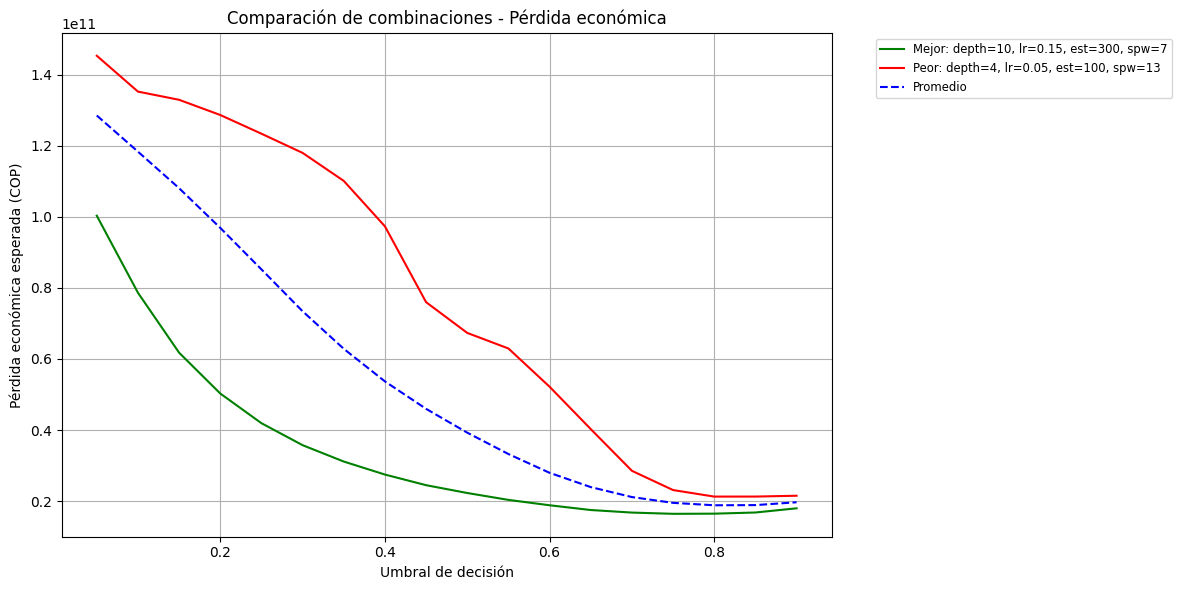

In [28]:
# Verificación de longitudes
longitud_umbrales = len(umbrales)
longitud_mejor = len(resultados[mejor_combinacion])
longitud_peor = len(resultados[peor_combinacion])
longitud_promedio = len(promedio_por_umbral)

if not (longitud_umbrales == longitud_mejor == longitud_peor == longitud_promedio):
    raise ValueError(f"Las longitudes no coinciden:\n"
                     f"umbrales = {longitud_umbrales}, "
                     f"mejor = {longitud_mejor}, "
                     f"peor = {longitud_peor}, "
                     f"promedio = {longitud_promedio}")

# Gráfica
plt.figure(figsize=(12, 6))

# Mejor combinación
plt.plot(umbrales, resultados[mejor_combinacion], 'g-', label=f"Mejor: {mejor_combinacion}")

# Peor combinación
plt.plot(umbrales, resultados[peor_combinacion], 'r-', label=f"Peor: {peor_combinacion}")

# Promedio de combinaciones
plt.plot(umbrales, promedio_por_umbral, 'b--', label=f"Promedio")

# Detalles
plt.title("Comparación de combinaciones - Pérdida económica")
plt.xlabel("Umbral de decisión")
plt.ylabel("Pérdida económica esperada (COP)")
plt.legend(fontsize='small', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()


In [21]:
# Crear y entrenar el modelo XGBoost
model_XGdef = XGBClassifier(
    n_estimators=300,
    max_depth=10,
    learning_rate=0.15,
    scale_pos_weight=7,
    use_label_encoder=False,
    eval_metric='logloss',
    verbosity=1
)

model_XGdef.fit(X_train, y_train)

model_XGdef.save_model('modelo_final_entrenado2.json')

# Obtener predicciones como probabilidades
y_proba_XGdef = model_XGdef.predict_proba(X_test)[:, 1]

# Aplicar umbral personalizado
umbral = 0.75
y_pred_XG_customedef = (y_proba_XGdef >= umbral).astype(int)


# Evaluación del modelo
print(f"\n Evaluación del modelo XGBoost con umbral = {umbral}\n")
print("Reporte de clasificación:")
print(classification_report(y_test, y_pred_XG_customedef, target_names=['No Adición', 'Adición']))

print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred_XG_customedef))

# Definir costos
costo_FN = veinte_por_ciento    # Dejar pasar una adición real
costo_FP = salario_equipo_revision_medio    # Revisar innecesariamente un contrato

# Obtener métricas de la matriz de confusión
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_XG_customedef).ravel()

# Calcular pérdida económica total
perdida_total = (fn * costo_FN) + (fp * costo_FP)

# Mostrar resultado
print(f"\nCosto total estimado con umbral = {umbral}: ${perdida_total:,.0f} COP")
print(fn,fp)

c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:183: UserWarning: [17:03:20] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



 Evaluación del modelo XGBoost con umbral = 0.75

Reporte de clasificación:
              precision    recall  f1-score   support

  No Adición       0.95      0.97      0.96     28350
     Adición       0.67      0.56      0.61      3486

    accuracy                           0.92     31836
   macro avg       0.81      0.76      0.78     31836
weighted avg       0.92      0.92      0.92     31836

Matriz de confusión:
[[27417   933]
 [ 1550  1936]]

Costo total estimado con umbral = 0.75: $16,394,945,104 COP
1550 933


In [22]:
Costoporcontrato=perdida_total/len(X_test)
Costoporcontrato

514981.3137333959

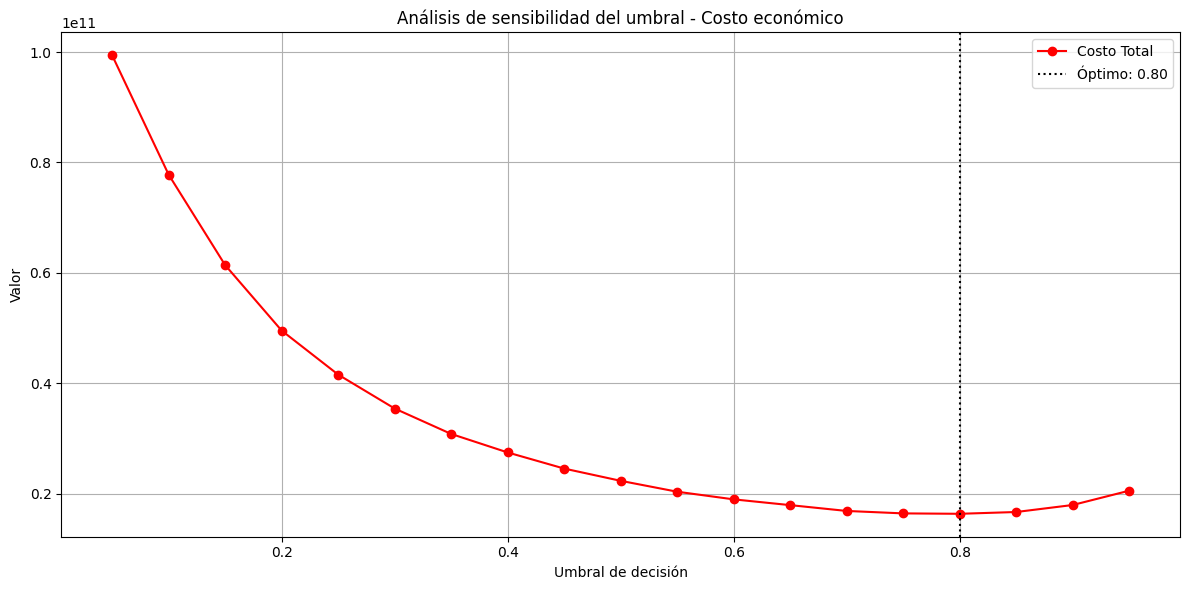

In [23]:
# Umbrales a probar
umbrales = np.arange(0.05, 0.96, 0.05)

# Resultados a guardar
falsos_positivos = []
falsos_negativos = []
costos = []

# Costos definidos
costo_FN = veinte_por_ciento
costo_FP = salario_equipo_revision_medio

# Calcular pérdida para cada umbral
for umbral_i in umbrales:
    y_pred_temp = (y_proba_XGdef >= umbral_i).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_temp).ravel()

    costo_total = (fn * costo_FN) + (fp * costo_FP)
    falsos_positivos.append(fp)
    falsos_negativos.append(fn)
    costos.append(costo_total)

# Encontrar umbral óptimo
idx_optimo = np.argmin(costos)
umbral_optimo = umbrales[idx_optimo]
costo_minimo = costos[idx_optimo]

# Graficar resultados
plt.figure(figsize=(12, 6))
plt.plot(umbrales, costos, label='Costo Total', color='red', marker='o')

plt.axvline(x=umbral_optimo, linestyle=':', color='black', label=f'Óptimo: {umbral_optimo:.2f}')
plt.title("Análisis de sensibilidad del umbral - Costo económico")
plt.xlabel("Umbral de decisión")
plt.ylabel("Valor")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [24]:
# Lista de umbrales con paso de 1%
umbrales = np.arange(0.05, 0.95, 0.01)

costos = []
fn_list = []
fp_list = []

# Evaluar costo por cada umbral
for umbral in umbrales:
    y_pred_umbral = (y_proba_XGdef >= umbral).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_umbral).ravel()
    costo = (fn * costo_FN) + (fp * costo_FP)
    costos.append(costo)
    fn_list.append(fn)
    fp_list.append(fp)

# Calcular sensibilidad: cambio porcentual del costo entre umbrales
cambios = [0]  # no hay cambio para el primero
for i in range(1, len(costos)):
    cambio = (costos[i] - costos[i-1]) / costos[i-1] * 100
    cambios.append(cambio)

# Mostrar resumen tabular de los principales cambios
import pandas as pd

tabla_sensibilidad = pd.DataFrame({
    'Umbral': umbrales,
    'Costo Total': costos,
    'Cambio % vs anterior': cambios,
    'FN': fn_list,
    'FP': fp_list
})

# Mostrar top cambios fuertes
pd.set_option('display.float_format', '{:,.2f}'.format)
display(tabla_sensibilidad.head(10))  # o .tail(10) o todo

# Sensibilidad media (absoluta)
sensibilidad_media = np.mean(np.abs(tabla_sensibilidad['Cambio % vs anterior'][1:]))  # sin el primero
print(f"Sensibilidad media: {sensibilidad_media:.2f}% por cada 1% de cambio en el umbral")


,Umbral,Costo Total,Cambio % vs anterior,FN,FP
0,0.05,"99,436,844,648.26",0.00,85,18502
1,0.06,"94,274,857,801.89",-5.19,102,17512
2,0.07,"90,026,832,368.46",-4.51,122,16689
3,0.08,"85,674,743,820.52",-4.83,146,15841
4,0.09,"81,578,276,179.91",-4.78,167,15045
5,0.10,"77,805,145,662.05",-4.63,200,14293
6,0.11,"73,880,301,797.31",-5.04,224,13525
7,0.12,"70,329,141,476.32",-4.81,240,12838
8,0.13,"67,297,467,138.88",-4.31,262,12240
9,0.14,"64,199,683,945.25",-4.60,283,11631


Sensibilidad media: 2.22% por cada 1% de cambio en el umbral


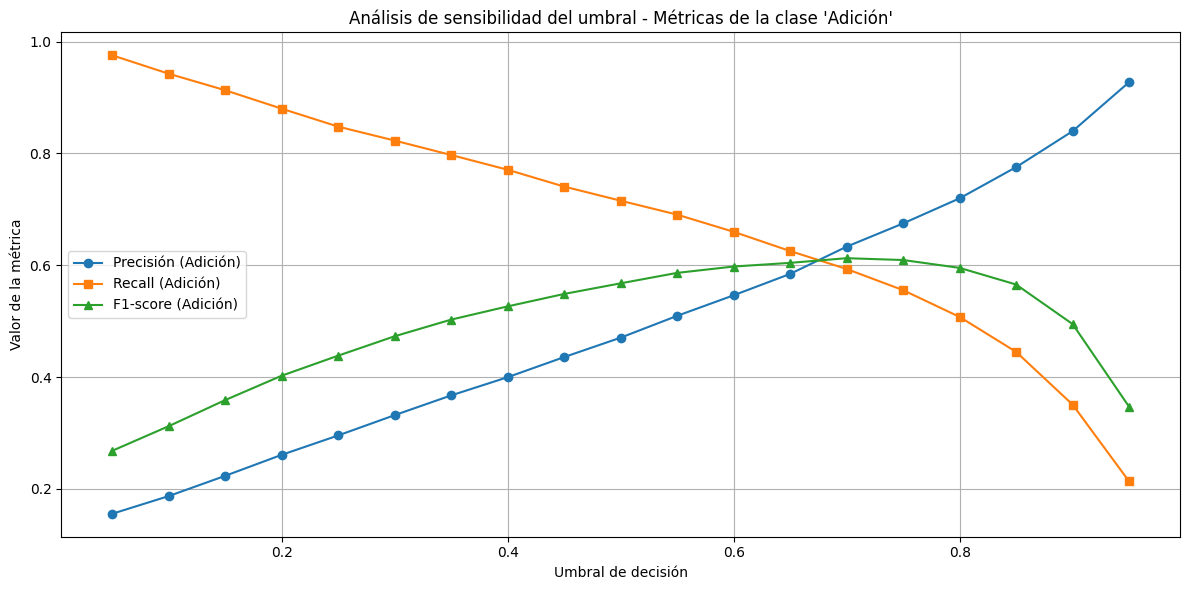

In [25]:


# Umbrales a probar
umbrales = np.arange(0.05, 0.96, 0.05)

# Resultados a guardar
precision_adicion = []
recall_adicion = []
f1_adicion = []

# Calcular métricas para cada umbral
for umbral_i in umbrales:
    y_pred_temp = (y_proba_XGdef >= umbral_i).astype(int)
    
    # Guardar métricas SOLO para la clase "Adición" (1)
    precision = precision_score(y_test, y_pred_temp, pos_label=1, zero_division=0)
    recall = recall_score(y_test, y_pred_temp, pos_label=1, zero_division=0)
    f1 = f1_score(y_test, y_pred_temp, pos_label=1, zero_division=0)
    
    precision_adicion.append(precision)
    recall_adicion.append(recall)
    f1_adicion.append(f1)

# Graficar
plt.figure(figsize=(12, 6))
plt.plot(umbrales, precision_adicion, label='Precisión (Adición)', marker='o')
plt.plot(umbrales, recall_adicion, label='Recall (Adición)', marker='s')
plt.plot(umbrales, f1_adicion, label='F1-score (Adición)', marker='^')

plt.title("Análisis de sensibilidad del umbral - Métricas de la clase 'Adición'")
plt.xlabel("Umbral de decisión")
plt.ylabel("Valor de la métrica")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


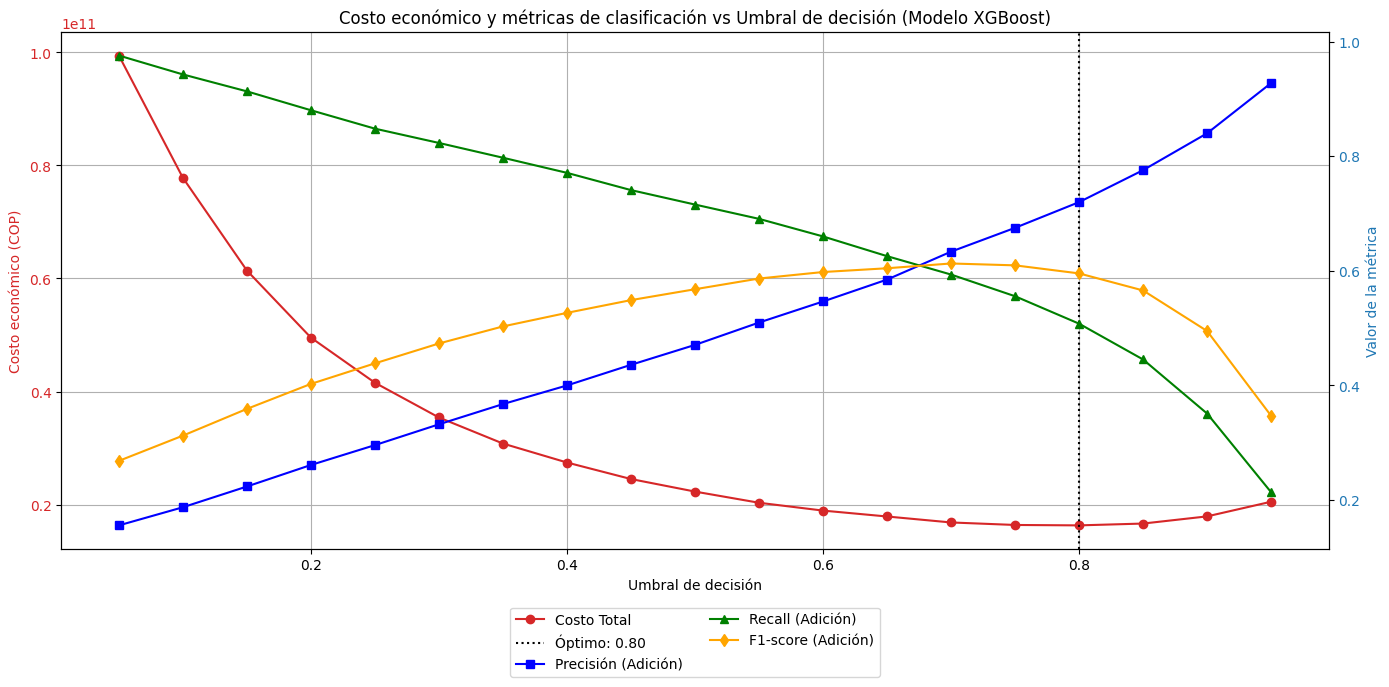

In [26]:
# --- Definiciones iniciales ---
umbrales = np.arange(0.05, 0.96, 0.05)

# Guardar resultados
falsos_positivos = []
falsos_negativos = []
costos = []
precision_adicion = []
recall_adicion = []
f1_adicion = []

# Costos definidos
costo_FN = veinte_por_ciento
costo_FP = salario_equipo_revision_medio

# --- Cálculos ---
for umbral_i in umbrales:
    y_pred_temp = (y_proba_XGdef >= umbral_i).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_temp).ravel()

    # Costo total
    costo_total = (fn * costo_FN) + (fp * costo_FP)
    costos.append(costo_total)

    # Métricas de clase "Adición"
    precision = precision_score(y_test, y_pred_temp, pos_label=1, zero_division=0)
    recall = recall_score(y_test, y_pred_temp, pos_label=1, zero_division=0)
    f1 = f1_score(y_test, y_pred_temp, pos_label=1, zero_division=0)
    
    precision_adicion.append(precision)
    recall_adicion.append(recall)
    f1_adicion.append(f1)

# Encontrar umbral óptimo (mínimo costo)
idx_optimo = np.argmin(costos)
umbral_optimo = umbrales[idx_optimo]
costo_minimo = costos[idx_optimo]

# --- Gráfico doble eje Y ---
fig, ax1 = plt.subplots(figsize=(14, 7))

# Primer eje (izquierdo) para Costo
color = 'tab:red'
ax1.set_xlabel('Umbral de decisión')
ax1.set_ylabel('Costo económico (COP)', color=color)
ax1.plot(umbrales, costos, label='Costo Total', color=color, marker='o')
ax1.tick_params(axis='y', labelcolor=color)
ax1.axvline(x=umbral_optimo, linestyle=':', color='black', label=f'Óptimo: {umbral_optimo:.2f}')
ax1.grid(True)

# Segundo eje (derecho) para Métricas
ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('Valor de la métrica', color=color)
ax2.plot(umbrales, precision_adicion, label='Precisión (Adición)', color='blue', marker='s')
ax2.plot(umbrales, recall_adicion, label='Recall (Adición)', color='green', marker='^')
ax2.plot(umbrales, f1_adicion, label='F1-score (Adición)', color='orange', marker='d')
ax2.tick_params(axis='y', labelcolor=color)

# Leyenda combinada
lines_labels_1 = ax1.get_legend_handles_labels()
lines_labels_2 = ax2.get_legend_handles_labels()
lines = lines_labels_1[0] + lines_labels_2[0]
labels = lines_labels_1[1] + lines_labels_2[1]
ax2.legend(lines, labels, loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=2)

# Título
plt.title('Costo económico y métricas de clasificación vs Umbral de decisión (Modelo XGBoost)')
plt.tight_layout()
plt.show()


Sensibilidad precio

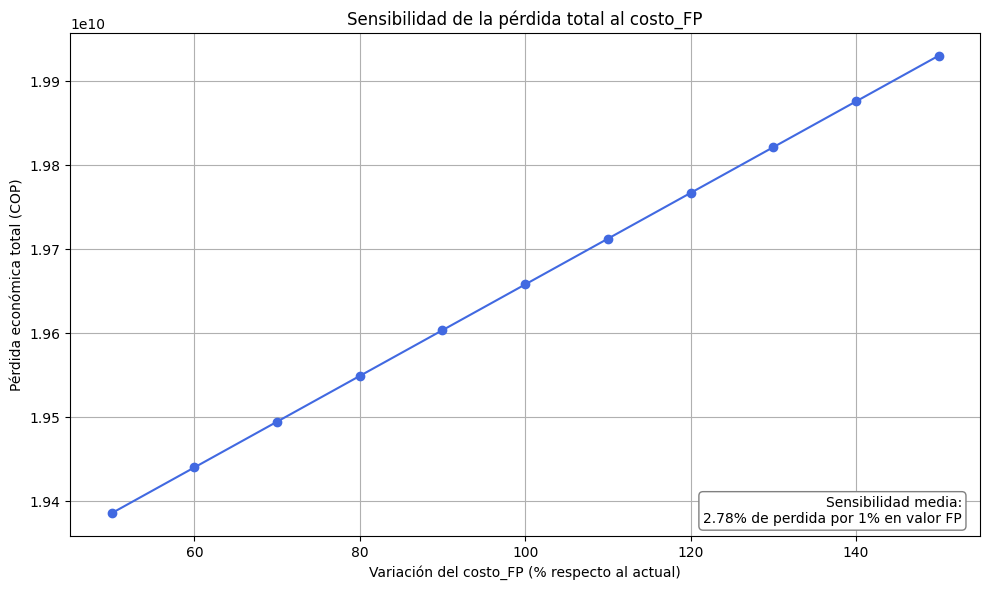

In [27]:
# Porcentajes de variación
porcentajes = np.array([0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5])
costos_FP = salario_equipo_revision_medio * porcentajes

# Predicciones con umbral fijo
y_pred_umbral_fijo = (y_proba_XGdef >= umbral).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_umbral_fijo).ravel()

# Cálculo de pérdidas
perdidas = [(fn * costo_FN) + (fp * cfp) for cfp in costos_FP]

# Calcular sensibilidad media (% cambio en pérdida por 1% cambio en costo_FP)
sensibilidades = []
for i in range(1, len(perdidas)):
    delta_costo = perdidas[i] - perdidas[i - 1]
    delta_porcentaje = (porcentajes[i] - porcentajes[i - 1]) * 100
    sensibilidad = (delta_costo / perdidas[i - 1]) / (delta_porcentaje / 100)
    sensibilidades.append(sensibilidad)

sensibilidad_media = np.mean(sensibilidades)

# Graficar
plt.figure(figsize=(10, 6))
plt.plot(porcentajes * 100, perdidas, marker='o', color='royalblue')
plt.title("Sensibilidad de la pérdida total al costo_FP")
plt.xlabel("Variación del costo_FP (% respecto al actual)")
plt.ylabel("Pérdida económica total (COP)")
plt.grid(True)

# Texto discreto con sensibilidad en la esquina
plt.text(0.98, 0.02, f"Sensibilidad media:\n{sensibilidad_media:.2%} de perdida por 1% en valor FP",
         transform=plt.gca().transAxes,
         fontsize=10, color='black', verticalalignment='bottom', horizontalalignment='right',
         bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray'))

plt.tight_layout()
plt.show()



Importancia caracteristicas

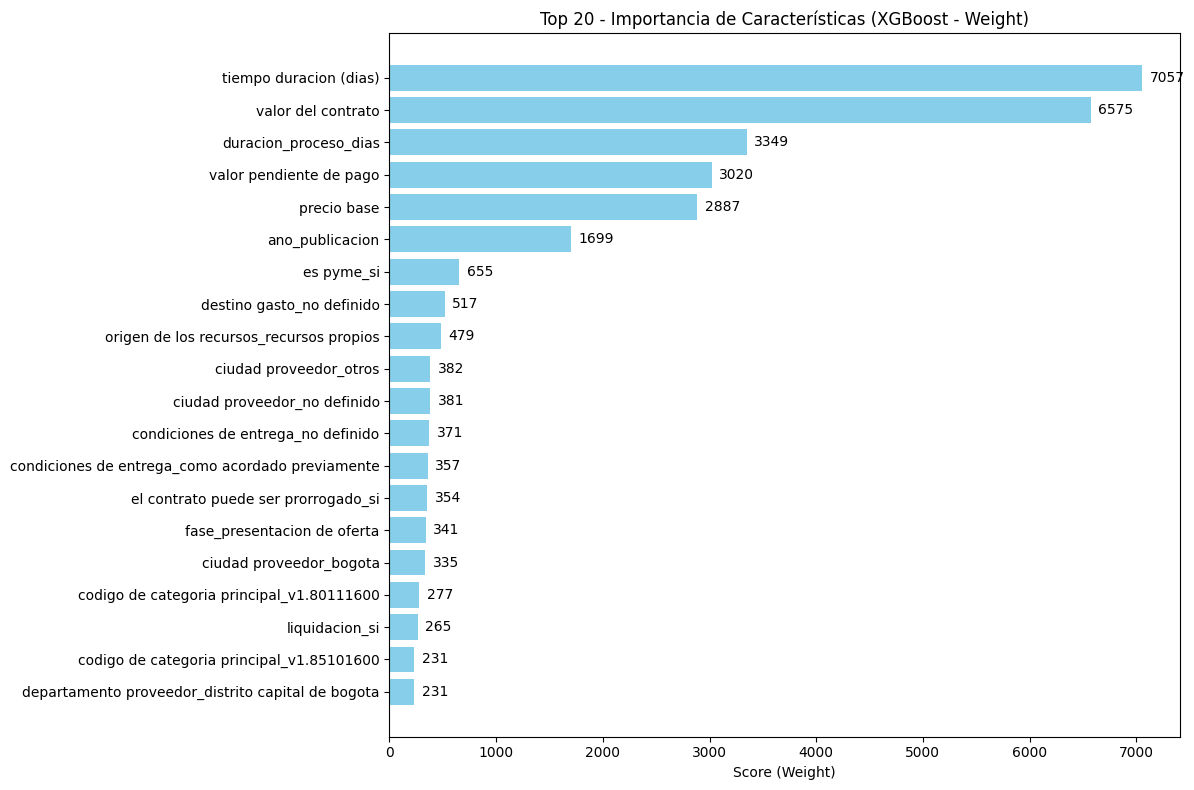

In [28]:
# Obtener el booster del modelo
booster = model_XGdef.get_booster()

# Extraer importancia tipo 'weight'
importancias = booster.get_score(importance_type='weight')

# Convertir a DataFrame
importancia_df = pd.DataFrame(importancias.items(), columns=['Feature', 'Importance'])

# Ordenar por importancia (Top 20)
importancia_df = importancia_df.sort_values(by='Importance', ascending=False).head(20)

# Gráfico de barras horizontal
plt.figure(figsize=(12, 8))
bars = plt.barh(importancia_df['Feature'][::-1], importancia_df['Importance'][::-1], color='skyblue')
plt.xlabel('Score (Weight)')
plt.title('Top 20 - Importancia de Características (XGBoost - Weight)')

# Añadir los valores numéricos a cada barra
for bar in bars:
    width = bar.get_width()
    plt.text(width + max(importancia_df['Importance']) * 0.01,  # Posición ligeramente a la derecha
             bar.get_y() + bar.get_height()/2,
             f'{width:.0f}',  # Valor sin decimales
             va='center')

plt.tight_layout()
plt.show()



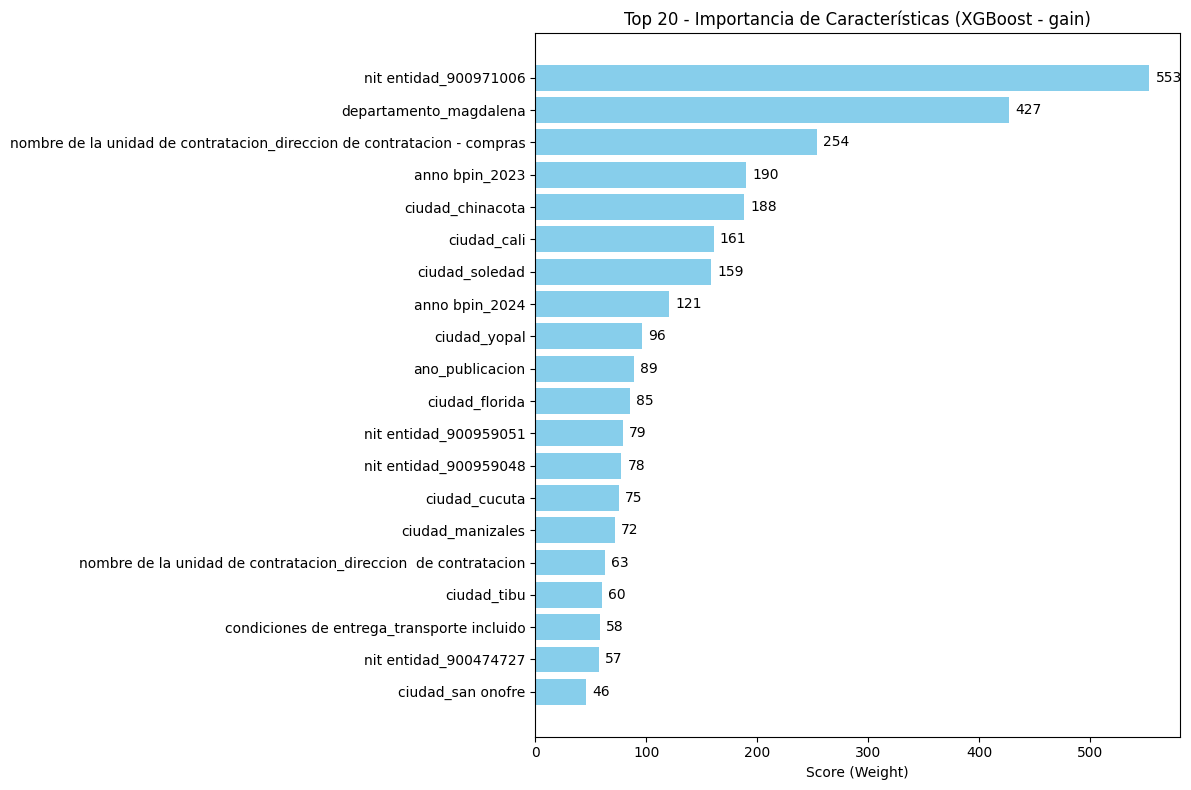

In [29]:


# Obtener el booster del modelo
booster = model_XGdef.get_booster()

# Extraer importancia tipo 'weight'
importancias = booster.get_score(importance_type='gain')

# Convertir a DataFrame
importancia_df = pd.DataFrame(importancias.items(), columns=['Feature', 'Importance'])

# Ordenar por importancia (Top 20)
importancia_df = importancia_df.sort_values(by='Importance', ascending=False).head(20)

# Gráfico de barras horizontal
plt.figure(figsize=(12, 8))
bars = plt.barh(importancia_df['Feature'][::-1], importancia_df['Importance'][::-1], color='skyblue')
plt.xlabel('Score (Weight)')
plt.title('Top 20 - Importancia de Características (XGBoost - gain)')

# Añadir los valores numéricos a cada barra
for bar in bars:
    width = bar.get_width()
    plt.text(width + max(importancia_df['Importance']) * 0.01,  # Posición ligeramente a la derecha
             bar.get_y() + bar.get_height()/2,
             f'{width:.0f}',  # Valor sin decimales
             va='center')

plt.tight_layout()
plt.show()


SHAP

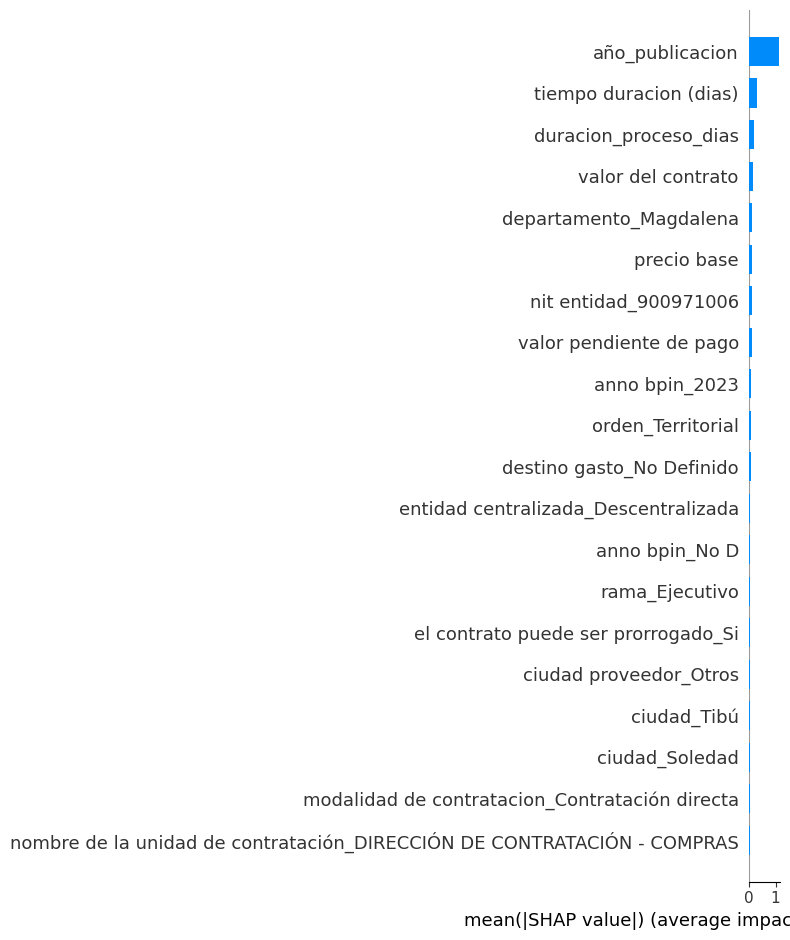

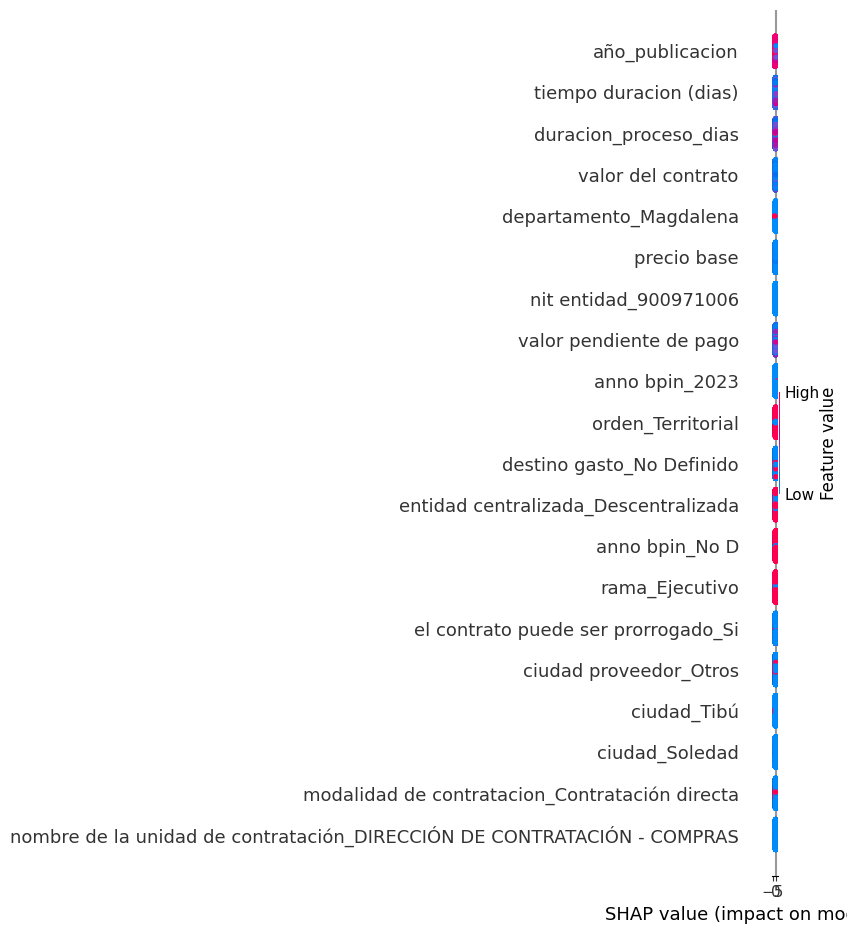

In [33]:
# Inicializar el explicador de SHAP para XGBoost
explainer = shap.TreeExplainer(model_XGdef)

# Calcular los valores SHAP (usa una muestra si tu dataset es muy grande)
shap_values = explainer.shap_values(X_test)

# -------------------------------
# 1️⃣ Resumen global de importancia
shap.summary_plot(shap_values, X_test, plot_type="bar")
# 2️⃣ Gráfico detallado de distribución SHAP
shap.summary_plot(shap_values, X_test)


Modelo reducido 

In [24]:
# 1. DataFrame con las dummies más importantes (ya calculado con XGBoost)
# Asume que este DataFrame se llama `importancia_df`
# y contiene las columnas 'Feature' y 'Importance'

# 2. Extraer variable original base de cada dummy
importancia_df['Variable_Original'] = importancia_df['Feature'].apply(lambda x: x.split('_')[0].strip())

# 3. Agrupar y sumar importancia por variable original
importancia_agrupada = (
    importancia_df.groupby('Variable_Original')['Importance']
    .sum()
    .reset_index()
    .sort_values(by='Importance', ascending=False)
)

# 4. Seleccionar las 10 variables originales más importantes
top10_vars = importancia_agrupada['Variable_Original'].head(15).tolist()

print("Top 10 variables originales más importantes:")
print(top10_vars)



Top 10 variables originales más importantes:
['nit entidad', 'ciudad', 'departamento', 'anno bpin', 'nombre de la unidad de contratación', 'año', 'condiciones de entrega']


In [25]:
#top10_vars=['tiempo duracion (dias)', 'valor del contrato', 'duracion_proceso_dias', 'valor pendiente de pago', 'precio base', 'año_publicacion', 'ciudad proveedor', 'condiciones de entrega', 'es pyme', 'origen de los recursos',
 #          'destino gasto', 'codigo de categoria principal', 'el contrato puede ser prorrogado', 'fase', 'liquidación', "Adicion"]

top10_vars=['tiempo duracion (dias)', 'valor del contrato', 'duracion_proceso_dias', 'valor pendiente de pago', 'precio base', 'año_publicacion', 'ciudad proveedor', 'condiciones de entrega', 'es pyme', 'origen de los recursos',
            'destino gasto', 'codigo de categoria principal',"Adicion"]

df_filtrado_top10 = df[top10_vars].copy()


df_dummies_final = pd.get_dummies(df_filtrado_top10, drop_first=True)
df_dummies_final

,tiempo duracion (dias),valor del contrato,duracion_proceso_dias,valor pendiente de pago,precio base,año_publicacion,Adicion,ciudad proveedor_Bogotá,ciudad proveedor_Bucaramanga,ciudad proveedor_Cali,...,codigo de categoria principal_V1.80111501,codigo de categoria principal_V1.80111600,codigo de categoria principal_V1.80111620,codigo de categoria principal_V1.80111700,codigo de categoria principal_V1.80111701,codigo de categoria principal_V1.80161500,codigo de categoria principal_V1.85101600,codigo de categoria principal_V1.85101601,codigo de categoria principal_V1.85101604,codigo de categoria principal_V1.93141500
0,38.00,"8,273,630.00",39.00,"4,136,815.00","8,273,630.00",2024,0,False,False,False,...,False,False,False,False,False,False,True,False,False,False
1,48.00,"5,272,122.00",53.00,"5,272,122.00","29,084,916.00",2020,1,True,False,False,...,False,True,False,False,False,False,False,False,False,False
2,50.00,"8,439,940.00",57.00,"8,439,940.00","59,079,580.00",2020,0,False,False,True,...,False,False,False,False,False,False,False,False,False,False
3,88.00,"34,408,800.00",90.00,"34,408,800.00","34,408,800.00",2018,1,False,False,False,...,False,False,False,False,False,False,True,False,False,False
4,57.00,"70,000,000.00",60.00,"70,000,000.00","70,000,000.00",2022,0,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
159178,27.00,"142,754,780.00",30.00,0.00,"142,754,780.00",2023,0,False,False,False,...,False,False,False,False,False,False,False,False,False,False
159179,145.00,"9,000,000.00",150.00,"9,000,000.00","9,000,000.00",2022,0,False,False,False,...,False,True,False,False,False,False,False,False,False,False
159180,30.00,"1,800,000.00",30.00,"1,800,000.00","1,800,000.00",2023,0,False,False,False,...,False,False,False,False,True,False,False,False,False,False
159181,175.00,"15,688,277.00",173.00,"15,688,277.00","15,688,277.00",2024,0,False,False,False,...,False,True,False,False,False,False,False,False,False,False


In [26]:
# Definir las características (X2) y la variable objetivo (y2)
X2 = df_dummies_final.drop('Adicion', axis=1)
y2 = df_dummies_final['Adicion']

# Dividir los datos en conjuntos de entrenamiento y prueba
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)

# Eliminar filas con valores nulos y sincronizar los índices
X2_train = X2_train.dropna()
y2_train = y2_train.loc[X2_train.index]

X2_test = X2_test.dropna()
y2_test = y2_test.loc[X2_test.index]


In [27]:
# Crear y entrenar el modelo con las variables seleccionadas (X2)
model_XGdef2 = XGBClassifier(
    n_estimators=300,
    max_depth=10,
    learning_rate=0.15,
    scale_pos_weight=7,
    use_label_encoder=False,
    eval_metric='logloss',
    verbosity=1
)

model_XGdef2.fit(X2_train, y2_train)

# Obtener predicciones como probabilidades
y_proba_XGdef2 = model_XGdef2.predict_proba(X2_test)[:, 1]

# Aplicar umbral personalizado
umbral = 0.75
y_pred_XG_customedef2 = (y_proba_XGdef2 >= umbral).astype(int)

# Evaluación del modelo
print(f"\nEvaluación del modelo XGBoost (variables seleccionadas) con umbral = {umbral}\n")
print("Reporte de clasificación:")
print(classification_report(y2_test, y_pred_XG_customedef2, target_names=['No Adición', 'Adición']))

print("Matriz de confusión:")
print(confusion_matrix(y2_test, y_pred_XG_customedef2))

# Costos definidos
costo_FN = veinte_por_ciento
costo_FP = salario_equipo_revision_medio

# Obtener métricas de la matriz de confusión
tn2, fp2, fn2, tp2 = confusion_matrix(y2_test, y_pred_XG_customedef2).ravel()

# Calcular pérdida económica total
perdida_total2 = (fn2 * costo_FN) + (fp2 * costo_FP)

# Mostrar resultado económico
print(f"\nCosto total estimado con umbral = {umbral}: ${perdida_total2:,.0f} COP")
print(f"FN = {fn2}, FP = {fp2}")


c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:183: UserWarning: [21:27:55] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Evaluación del modelo XGBoost (variables seleccionadas) con umbral = 0.75

Reporte de clasificación:
              precision    recall  f1-score   support

  No Adición       0.94      0.97      0.95     28350
     Adición       0.65      0.47      0.55      3486

    accuracy                           0.91     31836
   macro avg       0.80      0.72      0.75     31836
weighted avg       0.91      0.91      0.91     31836

Matriz de confusión:
[[27490   860]
 [ 1855  1631]]

Costo total estimado con umbral = 0.75: $18,250,711,567 COP
FN = 1855, FP = 860


## Random Forest

### Salario medio

In [ ]:

# Hiperparámetros a combinar
n_estimators_list = [100, 200,300]
max_depths = [None, 10, 20]
min_samples_splits = [2, 5,10]
min_samples_leafs = [1, 3,5]

# Costos
costo_FN = veinte_por_ciento  # Falso negativo (no detectar una adición)
costo_FP = salario_equipo_revision_medio  # Falso positivo (revisar contrato innecesario)

# Umbrales
umbrales = np.arange(0.1, 0.95, 0.05)
resultados_rf = {}

# Todas las combinaciones posibles
combinaciones = list(product(n_estimators_list, max_depths, min_samples_splits, min_samples_leafs))

# Evaluación por combinación
for n_est, max_d, min_split, min_leaf in combinaciones:
    model = RandomForestClassifier(
        n_estimators=n_est,
        max_depth=max_d,
        min_samples_split=min_split,
        min_samples_leaf=min_leaf,
        class_weight='balanced',
        random_state=42
    )
    model.fit(X_train, y_train)
    y_proba = model.predict_proba(X_test)[:, 1]

    perdidas = []
    for umbral in umbrales:
        y_pred = (y_proba >= umbral).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
        perdida = (fn * costo_FN) + (fp * costo_FP)
        perdidas.append(perdida)

    etiqueta = f"n={n_est}, depth={max_d}, split={min_split}, leaf={min_leaf}"
    resultados_rf[etiqueta] = perdidas

# Graficar resultados
plt.figure(figsize=(12, 8))
for nombre, perdidas in resultados_rf.items():
    plt.plot(umbrales, perdidas, label=nombre)

plt.axvline(x=0.5, color='gray', linestyle='--', label='Umbral 0.5')
plt.title("Pérdida esperada por umbral y combinación de hiperparámetros - Random Forest")
plt.xlabel("Umbral de decisión")
plt.ylabel("Pérdida económica esperada (COP)")
plt.grid(True)
plt.tight_layout()
plt.show()


KeyboardInterrupt: 

In [ ]:
# Inicializar valores
mejor_combinacion_rf = None
mejor_umbral_rf = None
mejor_perdida_rf = float('inf')

peor_combinacion_rf = None
peor_umbral_rf = None
peor_perdida_rf = float('-inf')

# Buscar mejor y peor combinación
for nombre, perdidas in resultados_rf.items():
    idx_min = np.argmin(perdidas)
    min_perdida = perdidas[idx_min]

    idx_max = np.argmax(perdidas)
    max_perdida = perdidas[idx_max]

    if min_perdida < mejor_perdida_rf:
        mejor_perdida_rf = min_perdida
        mejor_combinacion_rf = nombre
        mejor_umbral_rf = umbrales[idx_min]

    if max_perdida > peor_perdida_rf:
        peor_perdida_rf = max_perdida
        peor_combinacion_rf = nombre
        peor_umbral_rf = umbrales[idx_max]

# Calcular promedio por umbral (y mínimo del promedio)
promedio_por_umbral_rf = np.mean(np.array(list(resultados_rf.values())), axis=0)
idx_mejor_promedio_rf = np.argmin(promedio_por_umbral_rf)
mejor_umbral_promedio_rf = umbrales[idx_mejor_promedio_rf]
mejor_perdida_promedio_rf = promedio_por_umbral_rf[idx_mejor_promedio_rf]

# Mostrar resultados
print("\nMejor combinación (Random Forest):")
print(f"Parámetros: {mejor_combinacion_rf}")
print(f"Umbral óptimo: {mejor_umbral_rf:.2f}")
print(f"Pérdida mínima estimada: ${mejor_perdida_rf:,.0f} COP")

print("\nPeor combinación (Random Forest):")
print(f"Parámetros: {peor_combinacion_rf}")
print(f"Umbral más costoso: {peor_umbral_rf:.2f}")
print(f"Pérdida máxima estimada: ${peor_perdida_rf:,.0f} COP")

print("\nPromedio general (Random Forest):")
print(f"Umbral óptimo del promedio: {mejor_umbral_promedio_rf:.2f}")
print(f"Pérdida mínima promedio: ${mejor_perdida_promedio_rf:,.0f} COP")


Mejor combinación (Random Forest):
Parámetros: n=300, depth=None, split=10, leaf=1
Umbral óptimo: 0.60
Pérdida mínima estimada: $16,770,443,429 COP

Peor combinación (Random Forest):
Parámetros: n=100, depth=10, split=10, leaf=3
Umbral más costoso: 0.10
Pérdida máxima estimada: $150,849,416,521 COP

Promedio general (Random Forest):
Umbral óptimo del promedio: 0.70
Pérdida mínima promedio: $19,117,571,391 COP


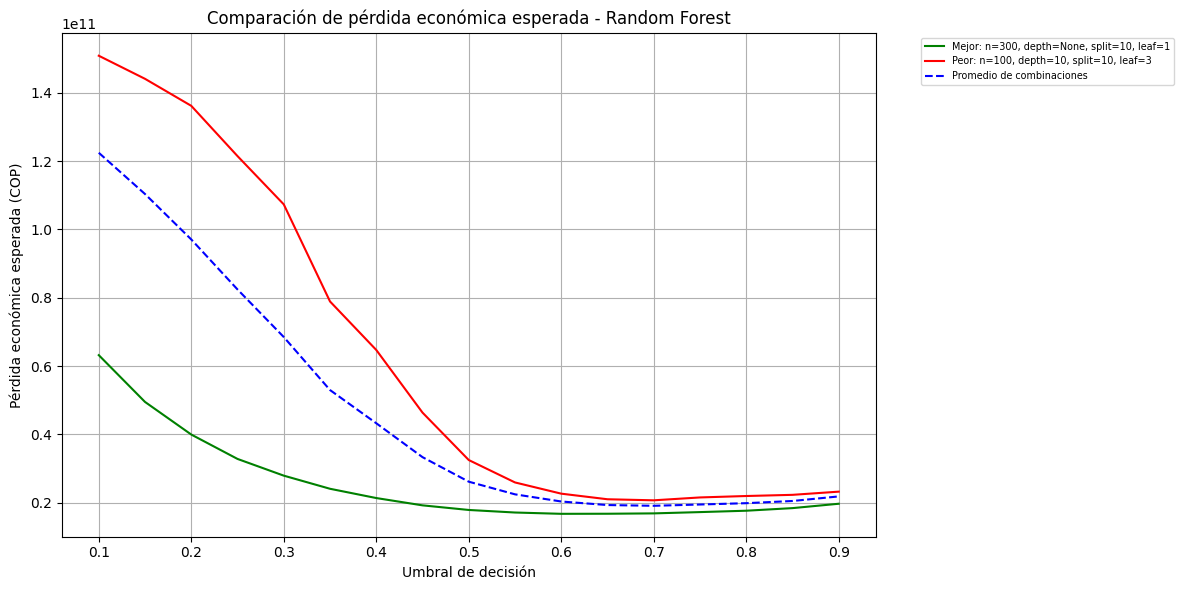

In [54]:
# Asegúrate de usar el mismo rango de umbrales con el que creaste los modelos
umbrales = np.arange(0.1, 0.95, 0.05)

# Verificar longitudes antes de graficar
longitud_umbrales = len(umbrales)
longitud_mejor = len(resultados_rf[mejor_combinacion_rf])
longitud_peor = len(resultados_rf[peor_combinacion_rf])
longitud_promedio = len(promedio_por_umbral_rf)

if not (longitud_umbrales == longitud_mejor == longitud_peor == longitud_promedio):
    raise ValueError(f"Las longitudes no coinciden:\n"
                     f"umbrales = {longitud_umbrales}, "
                     f"mejor = {longitud_mejor}, "
                     f"peor = {longitud_peor}, "
                     f"promedio = {longitud_promedio}")

# Graficar resultados
plt.figure(figsize=(12, 6))

# Mejor modelo
plt.plot(umbrales, resultados_rf[mejor_combinacion_rf], 'g-', label=f"Mejor: {mejor_combinacion_rf}")


# Peor modelo
plt.plot(umbrales, resultados_rf[peor_combinacion_rf], 'r-', label=f"Peor: {peor_combinacion_rf}")


# Promedio
plt.plot(umbrales, promedio_por_umbral_rf, 'b--', label="Promedio de combinaciones")


# Estética del gráfico
plt.title("Comparación de pérdida económica esperada - Random Forest")
plt.xlabel("Umbral de decisión")
plt.ylabel("Pérdida económica esperada (COP)")
plt.grid(True)
plt.legend(fontsize='x-small', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [34]:
# Crear y entrenar el modelo Random Forest
model_RF = RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_split=10,
        min_samples_leaf=1,
        class_weight='balanced',
        random_state=42)
# Entrenar el modelo
model_RF.fit(X_train, y_train)

# Hacer predicciones
y_pred_RF = model_RF.predict(X_test)

# Obtener probabilidades
y_proba_RF = model_RF.predict_proba(X_test)[:, 1]

# Aplicar umbral personalizado
umbralrf = 0.6  # por ejemplo
y_pred_RF_custom = (y_proba_RF >= umbralrf).astype(int)

print(f"\nEvaluación con umbral = {umbralrf}\n")
print(classification_report(y_test, y_pred_RF_custom, target_names=['No Adición', 'Adición']))
print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred_RF_custom))

# Definir costos
costo_FN = veinte_por_ciento    # Dejar pasar una adición real
costo_FP = salario_equipo_revision_medio    # Revisar innecesariamente un contrato

# Obtener métricas de la matriz de confusión
tnrf, fprf, fnrf, tprf = confusion_matrix(y_test, y_pred_RF_custom).ravel()

# Calcular pérdida económica total
perdida_totalrf = (fnrf * costo_FN) + (fprf* costo_FP)

# Mostrar resultado
print(f"\nCosto total estimado con umbral = {umbralrf}: ${perdida_totalrf:,.0f} COP")
print(fnrf,fprf)



Evaluación con umbral = 0.6

              precision    recall  f1-score   support

  No Adición       0.94      0.97      0.96     28350
     Adición       0.67      0.54      0.60      3486

    accuracy                           0.92     31836
   macro avg       0.81      0.75      0.78     31836
weighted avg       0.91      0.92      0.92     31836

Matriz de confusión:
[[27413   937]
 [ 1603  1883]]

Costo total estimado con umbral = 0.6: $16,806,531,087 COP
1603 937


In [35]:
Costoporcontratorf=perdida_totalrf/len(X_test)
Costoporcontratorf

527909.6333516088

In [36]:
# Rango de umbrales
umbrales = np.arange(0.05, 0.95, 0.01)

costos_rf = []
cambios_rf = [0]
fn_list_rf = []
fp_list_rf = []

# Calcular costo por cada umbral
for umbral in umbrales:
    y_pred = (y_proba_RF >= umbral).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    costo = (fn * costo_FN) + (fp * costo_FP)
    costos_rf.append(costo)
    fn_list_rf.append(fn)
    fp_list_rf.append(fp)

# Calcular cambio porcentual respecto al anterior
for i in range(1, len(costos_rf)):
    cambio = (costos_rf[i] - costos_rf[i-1]) / costos_rf[i-1] * 100
    cambios_rf.append(cambio)

# Tabla
tabla_sensibilidad_rf = pd.DataFrame({
    'Umbral': umbrales,
    'Costo Total': costos_rf,
    'Cambio % vs anterior': cambios_rf,
    'FN': fn_list_rf,
    'FP': fp_list_rf
})

# Mostrar primeras filas
pd.set_option('display.float_format', '{:,.2f}'.format)
display(tabla_sensibilidad_rf.head(10))

# Sensibilidad media (absoluta)
sensibilidad_media_rf = np.mean(np.abs(tabla_sensibilidad_rf['Cambio % vs anterior'][1:]))  # sin el primero
print(f"Sensibilidad media: {sensibilidad_media_rf:.2f}% por cada 1% de cambio en el umbral")



,Umbral,Costo Total,Cambio % vs anterior,FN,FP
0,0.05,"82,312,939,996.61",0.00,150,15206
1,0.06,"77,985,532,087.66",-5.26,173,14364
2,0.07,"73,954,602,954.71",-5.17,200,13572
3,0.08,"69,996,575,041.66",-5.35,234,12784
4,0.09,"66,898,377,053.55",-4.43,268,12157
5,0.10,"63,264,515,852.22",-5.43,288,11449
6,0.11,"59,996,560,687.90",-5.17,312,10804
7,0.12,"57,260,068,875.33",-4.56,340,10253
8,0.13,"54,586,211,960.08",-4.67,362,9722
9,0.14,"51,704,799,164.34",-5.28,387,9148


Sensibilidad media: 2.04% por cada 1% de cambio en el umbral


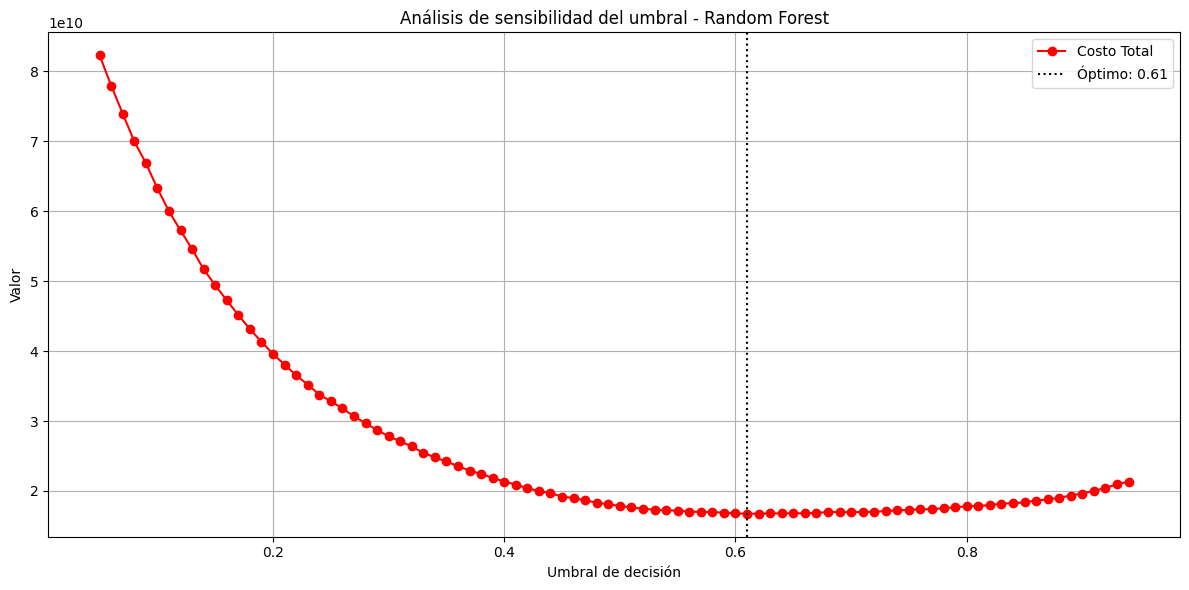

In [37]:
# Encontrar umbral de menor costo
idx_min_rf = np.argmin(costos_rf)
mejor_umbral_rf = umbrales[idx_min_rf]
mejor_costo_rf = costos_rf[idx_min_rf]

plt.figure(figsize=(12, 6))

# Línea de costo
plt.plot(umbrales, costos_rf, 'o-r', label='Costo Total')



# Línea vertical de umbral óptimo
plt.axvline(mejor_umbral_rf, color='black', linestyle=':', label=f'Óptimo: {mejor_umbral_rf:.2f}')

plt.title("Análisis de sensibilidad del umbral - Random Forest")
plt.xlabel("Umbral de decisión")
plt.ylabel("Valor")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Sensibilidad precio

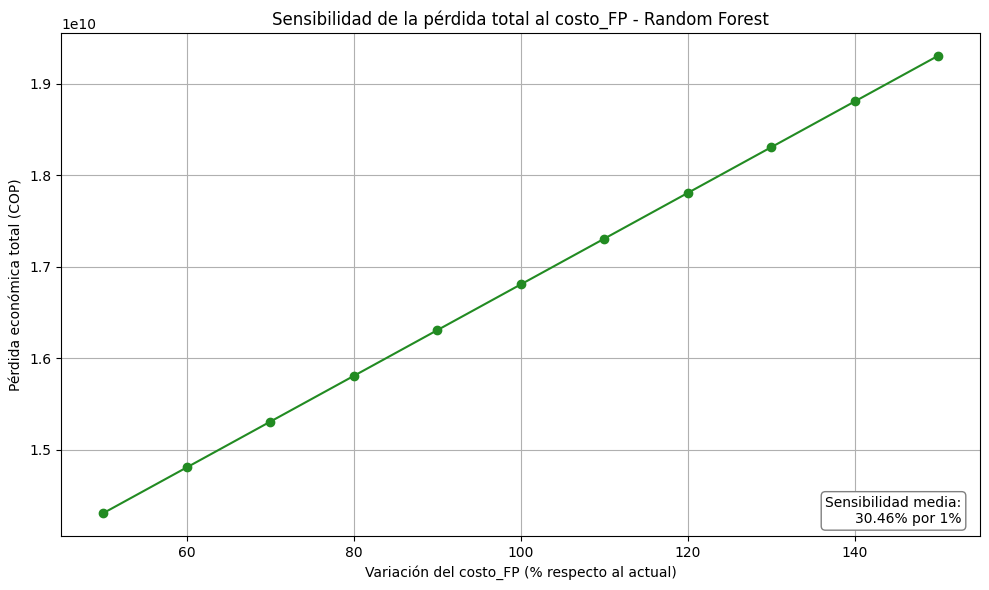

In [38]:
# Porcentajes de variación del costo_FP (50% a 150%)
porcentajes = np.array([0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5])
costos_FP = salario_equipo_revision_medio * porcentajes

# Predicciones con el umbral fijo
y_pred_RF_custom = (y_proba_RF >= umbralrf).astype(int)
tnrf, fprf, fnrf, tprf = confusion_matrix(y_test, y_pred_RF_custom).ravel()

# Calcular pérdidas para cada costo_FP
perdidas_rf = [(fnrf * costo_FN) + (fprf * cfp) for cfp in costos_FP]

# Sensibilidad media: % cambio pérdida / % cambio costo_FP
sensibilidades_rf = []
for i in range(1, len(perdidas_rf)):
    delta_costo = perdidas_rf[i] - perdidas_rf[i - 1]
    delta_pct = (porcentajes[i] - porcentajes[i - 1]) * 100
    sensibilidad = (delta_costo / perdidas_rf[i - 1]) / (delta_pct / 100)
    sensibilidades_rf.append(sensibilidad)

sensibilidad_media_rf = np.mean(sensibilidades_rf)

# Graficar
plt.figure(figsize=(10, 6))
plt.plot(porcentajes * 100, perdidas_rf, marker='o', color='forestgreen')
plt.title("Sensibilidad de la pérdida total al costo_FP - Random Forest")
plt.xlabel("Variación del costo_FP (% respecto al actual)")
plt.ylabel("Pérdida económica total (COP)")
plt.grid(True)

# Agregar sensibilidad media como texto discreto
plt.text(0.98, 0.02, f"Sensibilidad media:\n{sensibilidad_media_rf:.2%} por 1%",
         transform=plt.gca().transAxes,
         fontsize=10, color='black', verticalalignment='bottom', horizontalalignment='right',
         bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray'))

plt.tight_layout()
plt.show()


Importancia caracteristicas

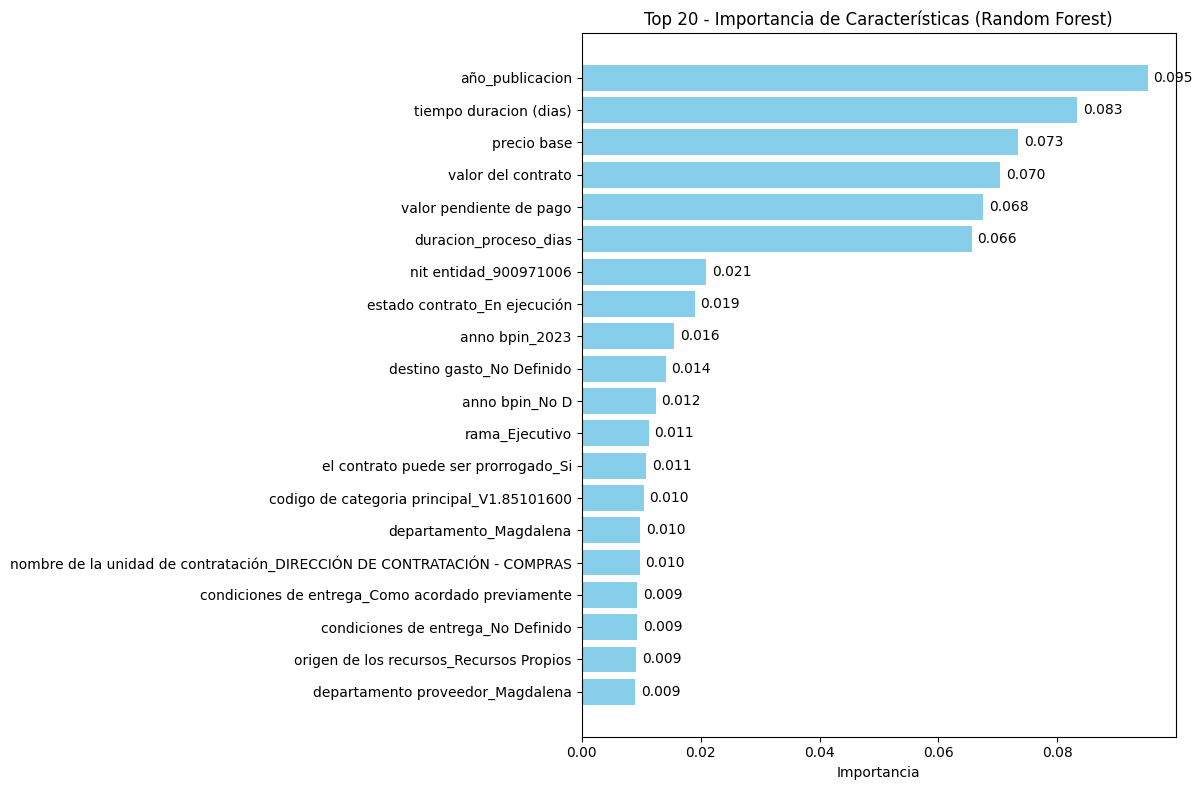

In [39]:
# Obtener la importancia de características del modelo Random Forest
importancias_rf = model_RF.feature_importances_

# Crear DataFrame ordenado
importancia_rf_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importancias_rf
}).sort_values(by='Importance', ascending=False).head(20)

# Gráfico de barras horizontal
plt.figure(figsize=(12, 8))
bars = plt.barh(importancia_rf_df['Feature'][::-1], importancia_rf_df['Importance'][::-1], color='skyblue')
plt.xlabel('Importancia')
plt.title('Top 20 - Importancia de Características (Random Forest)')

# Añadir los valores numéricos a cada barra
for bar in bars:
    width = bar.get_width()
    plt.text(width + max(importancia_rf_df['Importance']) * 0.01,   # Ajuste de posición
             bar.get_y() + bar.get_height()/2,
             f'{width:.3f}',    # Tres decimales para mayor detalle en RF
             va='center')

plt.tight_layout()
plt.show()


## Modelo LGB

### Salario medio

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 14468, number of negative: 112877
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008634 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1888
[LightGBM] [Info] Number of data points in the train set: 127345, number of used features: 307
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

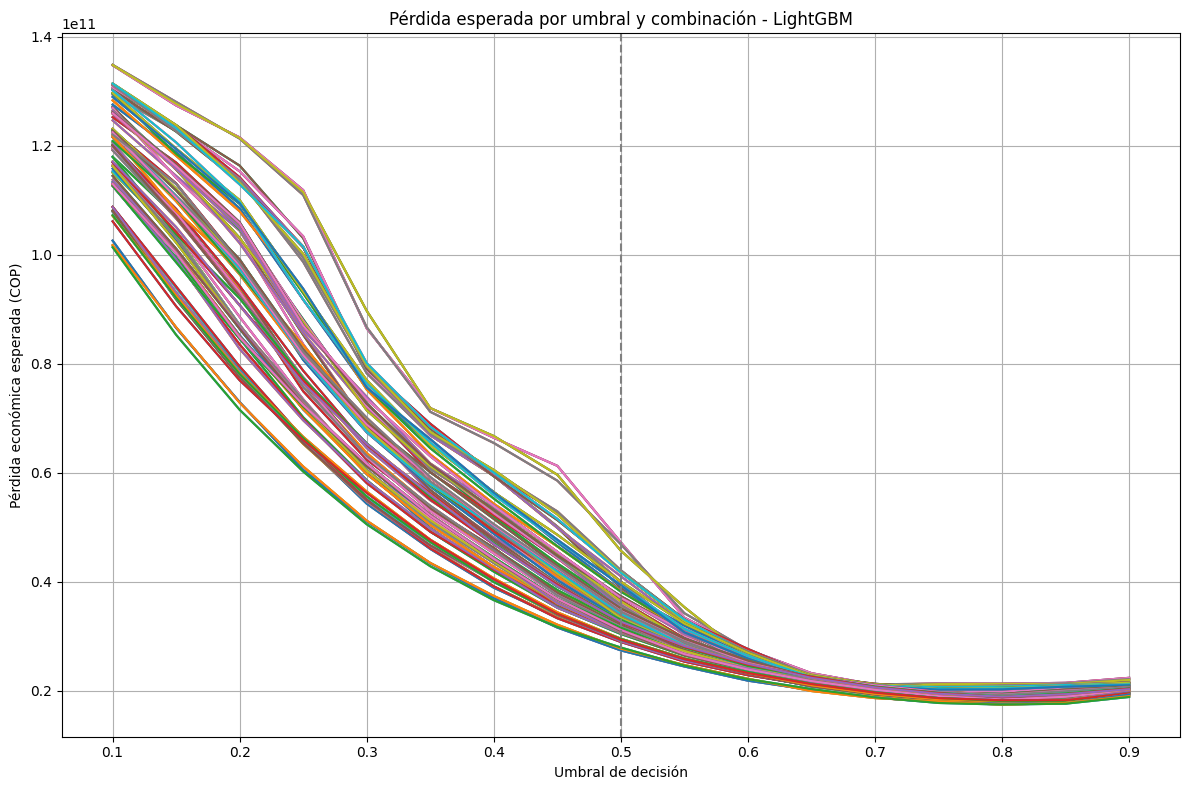

In [80]:
# Hiperparámetros a probar
n_estimators_list = [100, 200, 300]
learning_rates = [0.05, 0.1, 0.15]
max_depths = [4, 6, -1]
subsamples = [0.6, 0.8, 1.0]
colsample_bytree_list = [0.6, 0.8, 1.0] 

# Costos (ajústalos según tu contexto)
costo_FN = veinte_por_ciento              # Costo por no detectar una adición
costo_FP = salario_equipo_revision_medio   # Costo por revisar un contrato que no era adición

# Umbrales
umbrales = np.arange(0.1, 0.95, 0.05)

# Diccionario para guardar resultados
resultados_lgb = {}

# Crear todas las combinaciones posibles de hiperparámetros
combinaciones = list(product(n_estimators_list, learning_rates, max_depths, subsamples, colsample_bytree_list))

for n_est, lr, max_d, subsample, colsample in combinaciones:
    # Definir el modelo
    model = lgb.LGBMClassifier(
        n_estimators=n_est,
        learning_rate=lr,
        max_depth=max_d,
        subsample=subsample,
        colsample_bytree=colsample,
        class_weight='balanced',
        random_state=42
    )
    
    # Entrenar
    model.fit(X_train, y_train)
    
    # Predecir probabilidades
    y_proba = model.predict_proba(X_test)[:, 1]
    
    # Evaluar pérdidas para cada umbral
    perdidas = []
    for umbral in umbrales:
        y_pred = (y_proba >= umbral).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
        perdida = (fn * costo_FN) + (fp * costo_FP)
        perdidas.append(perdida)
    
    # Guardar resultados
    etiqueta = f"LGB: est={n_est}, lr={lr}, depth={max_d}, sub={subsample}, col={colsample}"
    resultados_lgb[etiqueta] = perdidas


# Graficar todas las combinaciones
plt.figure(figsize=(12, 8))
for nombre, perdidas in resultados_lgb.items():
    plt.plot(umbrales, perdidas, label=nombre)

plt.axvline(x=0.5, color='gray', linestyle='--', label='Umbral 0.5')
plt.title("Pérdida esperada por umbral y combinación - LightGBM")
plt.xlabel("Umbral de decisión")
plt.ylabel("Pérdida económica esperada (COP)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [81]:
# Inicializar valores
mejor_combinacion_lgb = None
mejor_umbral_lgb = None
mejor_perdida_lgb = float('inf')

peor_combinacion_lgb = None
peor_umbral_lgb = None
peor_perdida_lgb = float('-inf')

# Evaluar combinaciones
for nombre, perdidas in resultados_lgb.items():
    idx_min = np.argmin(perdidas)
    min_perdida = perdidas[idx_min]

    idx_max = np.argmax(perdidas)
    max_perdida = perdidas[idx_max]

    if min_perdida < mejor_perdida_lgb:
        mejor_perdida_lgb = min_perdida
        mejor_combinacion_lgb = nombre
        mejor_umbral_lgb = umbrales[idx_min]

    if max_perdida > peor_perdida_lgb:
        peor_perdida_lgb = max_perdida
        peor_combinacion_lgb = nombre
        peor_umbral_lgb = umbrales[idx_max]

# Calcular promedio de pérdidas por umbral
promedio_por_umbral_lgb = np.mean(np.array(list(resultados_lgb.values())), axis=0)
idx_mejor_promedio_lgb = np.argmin(promedio_por_umbral_lgb)
mejor_umbral_promedio_lgb = umbrales[idx_mejor_promedio_lgb]
mejor_perdida_promedio_lgb = promedio_por_umbral_lgb[idx_mejor_promedio_lgb]

# Mostrar resultados
print("\nMejor combinación (LightGBM):")
print(f"Parámetros: {mejor_combinacion_lgb}")
print(f"Umbral óptimo: {mejor_umbral_lgb:.2f}")
print(f"Pérdida mínima estimada: ${mejor_perdida_lgb:,.0f} COP")

print("\nPeor combinación (LightGBM):")
print(f"Parámetros: {peor_combinacion_lgb}")
print(f"Umbral más costoso: {peor_umbral_lgb:.2f}")
print(f"Pérdida máxima estimada: ${peor_perdida_lgb:,.0f} COP")

print("\nPromedio general (LightGBM):")
print(f"Umbral óptimo del promedio: {mejor_umbral_promedio_lgb:.2f}")
print(f"Pérdida mínima promedio: ${mejor_perdida_promedio_lgb:,.0f} COP")


Mejor combinación (LightGBM):
Parámetros: LGB: est=300, lr=0.15, depth=-1, sub=0.6, col=0.8
Umbral óptimo: 0.80
Pérdida mínima estimada: $17,465,908,653 COP

Peor combinación (LightGBM):
Parámetros: LGB: est=100, lr=0.05, depth=4, sub=0.6, col=0.8
Umbral más costoso: 0.10
Pérdida máxima estimada: $134,887,938,850 COP

Promedio general (LightGBM):
Umbral óptimo del promedio: 0.80
Pérdida mínima promedio: $19,302,457,945 COP


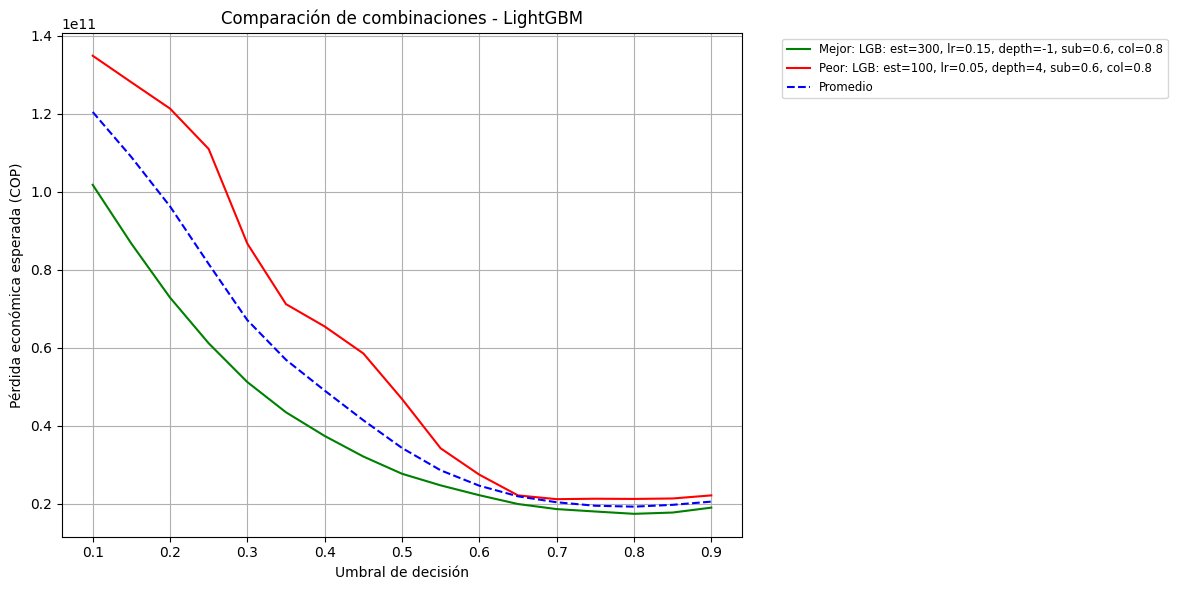

In [82]:
# Validar longitudes antes de graficar
assert len(umbrales) == len(resultados_lgb[mejor_combinacion_lgb]) == len(resultados_lgb[peor_combinacion_lgb]) == len(promedio_por_umbral_lgb)

# Gráfica
plt.figure(figsize=(12, 6))

# Mejor
plt.plot(umbrales, resultados_lgb[mejor_combinacion_lgb], 'g-', label=f"Mejor: {mejor_combinacion_lgb}")

# Peor
plt.plot(umbrales, resultados_lgb[peor_combinacion_lgb], 'r-', label=f"Peor: {peor_combinacion_lgb}")

# Promedio
plt.plot(umbrales, promedio_por_umbral_lgb, 'b--', label="Promedio")

# Detalles
plt.title("Comparación de combinaciones - LightGBM")
plt.xlabel("Umbral de decisión")
plt.ylabel("Pérdida económica esperada (COP)")
plt.legend(fontsize='small', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

In [40]:
# Crear y entrenar el modelo LightGBM
model_LGB = lgb.LGBMClassifier(
    n_estimators=300,          # Número de árboles
    max_depth=-1,              # Sin límite de profundidad
    learning_rate=0.15,        # Tasa de aprendizaje
    subsample=0.6,             # Proporción de datos para cada árbol
    colsample_bytree=0.8,      # Proporción de características para cada árbol
    class_weight='balanced',   # Manejo de clases desbalanceadas
    random_state=42            # Para reproducibilidad
)

# Entrenar el modelo
model_LGB.fit(X_train, y_train)

# Definir el umbral deseado
umbral_lgb = 0.8  # Puedes cambiarlo según lo que quieras probar

# Predecir probabilidades
y_proba_LGB = model_LGB.predict_proba(X_test)[:, 1]

# Aplicar umbral personalizado
y_pred_LGB_custom = (y_proba_LGB >= umbral_lgb).astype(int)

# Evaluación
print(f"\nEvaluación del modelo LightGBM con umbral = {umbral_lgb}\n")
print("Reporte de clasificación:")
print(classification_report(y_test, y_pred_LGB_custom, target_names=['No Adición', 'Adición']))

# Matriz de confusión
conf_matrix_LGB = confusion_matrix(y_test, y_pred_LGB_custom)
print("\nMatriz de confusión:")
print(conf_matrix_LGB)

# Definir costos
costo_FN = veinte_por_ciento    # Dejar pasar una adición real
costo_FP = salario_equipo_revision_medio               # Revisar innecesariamente un contrato

# Obtener métricas de la matriz de confusión
tnlgb, fplgb, fnlgb, tplgb = conf_matrix_LGB.ravel()

# Calcular pérdida económica total
perdida_total_lgb = (fnlgb * costo_FN) + (fplgb * costo_FP)

# Mostrar resultado
print(f"\nCosto total estimado con umbral = {umbral_lgb}: ${perdida_total_lgb:,.0f} COP")
print(f"FN = {fnlgb}, FP = {fplgb}")

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 14468, number of negative: 112877
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008091 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1866
[LightGBM] [Info] Number of data points in the train set: 127345, number of used features: 296
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000

Evaluación del modelo LightGBM con umbral = 0.8

Reporte de clasificación:
              precision    recall  f1-score   support

  No Adición       0.94      0.97      0.95     28350
     Adición       0.66      0.51      0.57      3486

    accuracy                           0.92     31836
   macro avg       0.80      0.74      0.76     31836
weighted avg 

In [41]:
Costoporcontratolgb=perdida_total_lgb/len(X_test)
Costoporcontratolgb

550062.6954313272

In [42]:
# Rango de umbrales
umbrales = np.arange(0.05, 0.95, 0.01)

costos_lgb = []
cambios_lgb = [0]
fn_list_lgb = []
fp_list_lgb = []

# Evaluar cada umbral
for umbral in umbrales:
    y_pred = (y_proba_LGB >= umbral).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    costo = (fn * costo_FN) + (fp * costo_FP)
    costos_lgb.append(costo)
    fn_list_lgb.append(fn)
    fp_list_lgb.append(fp)

# Cambios porcentuales entre umbrales
for i in range(1, len(costos_lgb)):
    cambio = (costos_lgb[i] - costos_lgb[i-1]) / costos_lgb[i-1] * 100
    cambios_lgb.append(cambio)

# Tabla resumen
tabla_sensibilidad_lgb = pd.DataFrame({
    'Umbral': umbrales,
    'Costo Total': costos_lgb,
    'Cambio % vs anterior': cambios_lgb,
    'FN': fn_list_lgb,
    'FP': fp_list_lgb
})

pd.set_option('display.float_format', '{:,.2f}'.format)
display(tabla_sensibilidad_lgb.head(10))  # Puedes cambiar a .tail() o mostrar todo

# Sensibilidad media (absoluta)
sensibilidad_media_lgb = np.mean(np.abs(tabla_sensibilidad_lgb['Cambio % vs anterior'][1:]))  # sin el primero
print(f"Sensibilidad media: {sensibilidad_media_lgb:.2f}% por cada 1% de cambio en el umbral")


,Umbral,Costo Total,Cambio % vs anterior,FN,FP
0,0.05,"117,454,800,283.85",0.00,29,21953
1,0.06,"114,545,647,684.72",-2.48,35,21400
2,0.07,"111,107,779,790.14",-3.00,41,20748
3,0.08,"107,796,063,146.80",-2.98,46,20121
4,0.09,"104,815,616,687.00",-2.76,59,19545
5,0.10,"101,337,772,380.39",-3.32,69,18880
6,0.11,"97,792,522,966.47",-3.50,80,18201
7,0.12,"94,767,329,884.64",-3.09,92,17618
8,0.13,"91,819,497,124.62",-3.11,100,17055
9,0.14,"88,749,557,420.76",-3.34,111,16465


Sensibilidad media: 2.30% por cada 1% de cambio en el umbral


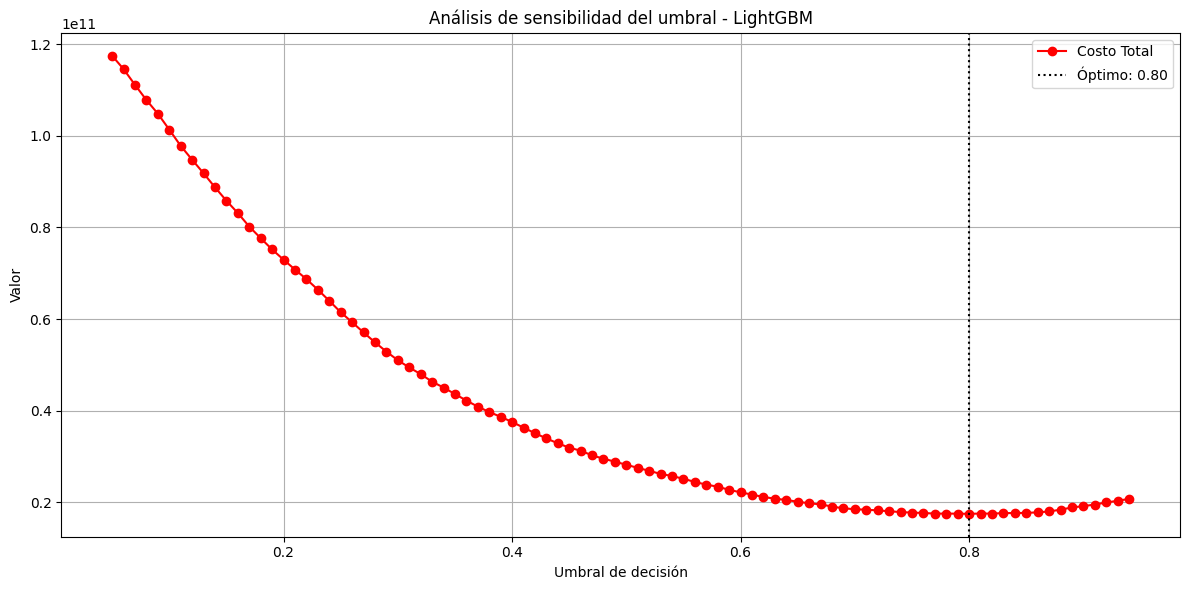

In [43]:
# Encontrar umbral de menor costo
idx_min_lgb = np.argmin(costos_lgb)
mejor_umbral_lgb = umbrales[idx_min_lgb]
mejor_costo_lgb = costos_lgb[idx_min_lgb]

plt.figure(figsize=(12, 6))

# Línea de costo
plt.plot(umbrales, costos_lgb, 'o-r', label='Costo Total')



# Umbral óptimo
plt.axvline(mejor_umbral_lgb, color='black', linestyle=':', label=f'Óptimo: {mejor_umbral_lgb:.2f}')

plt.title("Análisis de sensibilidad del umbral - LightGBM")
plt.xlabel("Umbral de decisión")
plt.ylabel("Valor")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Sensibilidad precio

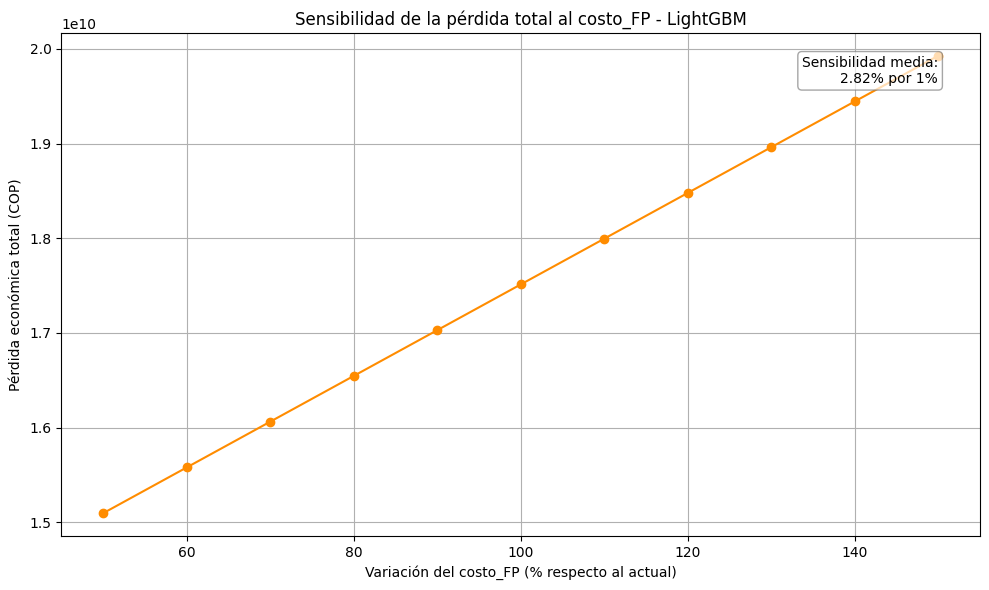

In [44]:
# Porcentajes de variación (de 50% a 150%)
porcentajes = np.array([0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5])
costos_FP_variados = salario_equipo_revision_medio * porcentajes

# Usar predicciones ya calculadas
y_pred_umbral_fijo = (y_proba_LGB >= umbral_lgb).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_umbral_fijo).ravel()

# Calcular pérdidas con FP variable
perdidas = [(fn * costo_FN) + (fp * costo_fp) for costo_fp in costos_FP_variados]

# Calcular sensibilidad media (promedio de diferencias porcentuales)
porcentajes_cambio = porcentajes * 100
variaciones_pct = [(perdidas[i+1] - perdidas[i]) / perdidas[i] * 100 for i in range(len(perdidas)-1)]
sensibilidad_media = np.mean(variaciones_pct)

# Graficar
plt.figure(figsize=(10, 6))
plt.plot(porcentajes_cambio, perdidas, marker='o', color='darkorange')
plt.title("Sensibilidad de la pérdida total al costo_FP - LightGBM")
plt.xlabel("Variación del costo_FP (% respecto al actual)")
plt.ylabel("Pérdida económica total (COP)")
plt.grid(True)

# Agregar texto con la sensibilidad media
plt.text(porcentajes_cambio[-1], perdidas[-1],
         f"Sensibilidad media:\n{sensibilidad_media:.2f}% por 1%",
         fontsize=10,
         verticalalignment='top',
         horizontalalignment='right',
         bbox=dict(boxstyle="round,pad=0.3", edgecolor="gray", facecolor="white", alpha=0.7))

plt.tight_layout()
plt.show()


Importancia caracteristicas

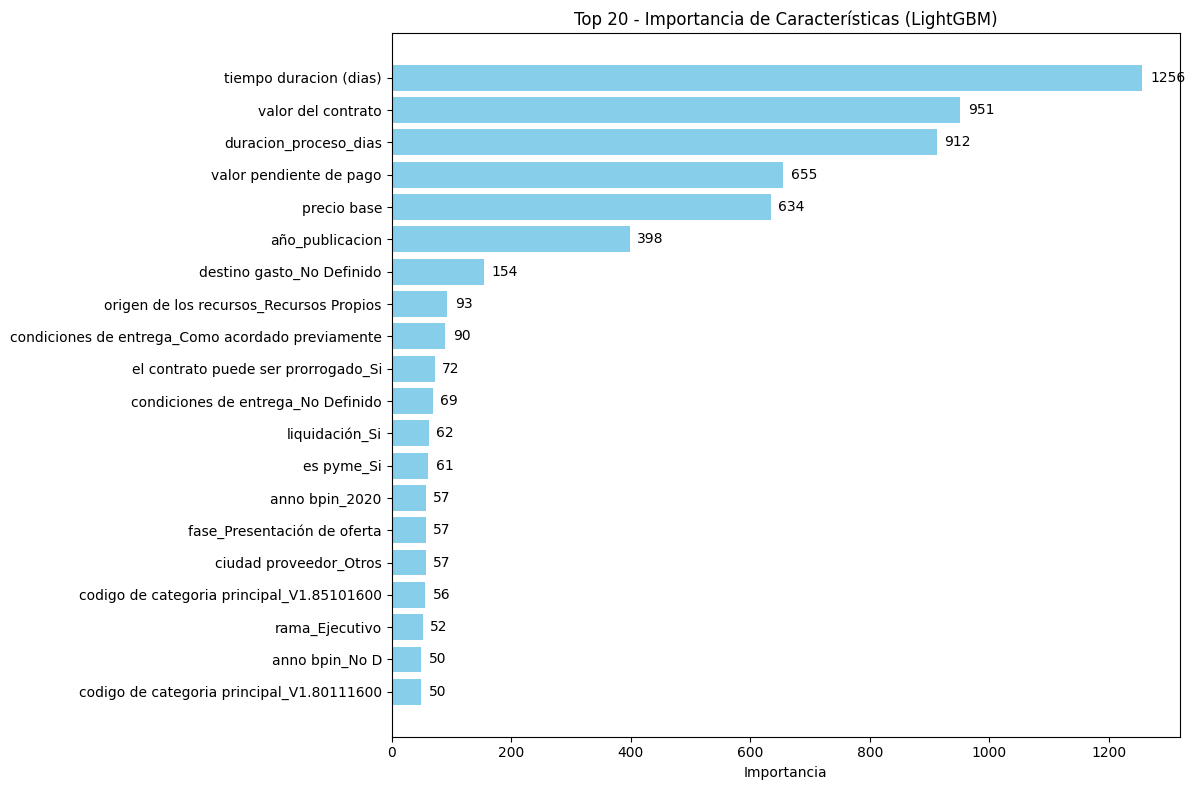

In [45]:
# Obtener la importancia de características del modelo LightGBM
importancias_lgb = model_LGB.feature_importances_

# Crear DataFrame ordenado
importancia_lgb_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importancias_lgb
}).sort_values(by='Importance', ascending=False).head(20)

# Gráfico de barras horizontal con valores
plt.figure(figsize=(12, 8))
bars = plt.barh(importancia_lgb_df['Feature'][::-1], importancia_lgb_df['Importance'][::-1], color='skyblue')
plt.xlabel('Importancia')
plt.title('Top 20 - Importancia de Características (LightGBM)')

# Añadir los valores numéricos a cada barra
for bar in bars:
    width = bar.get_width()
    plt.text(width + max(importancia_lgb_df['Importance']) * 0.01,  # Posición del texto
             bar.get_y() + bar.get_height() / 2,
             f'{int(width)}',  # Mostrar número entero
             va='center')

plt.tight_layout()
plt.show()


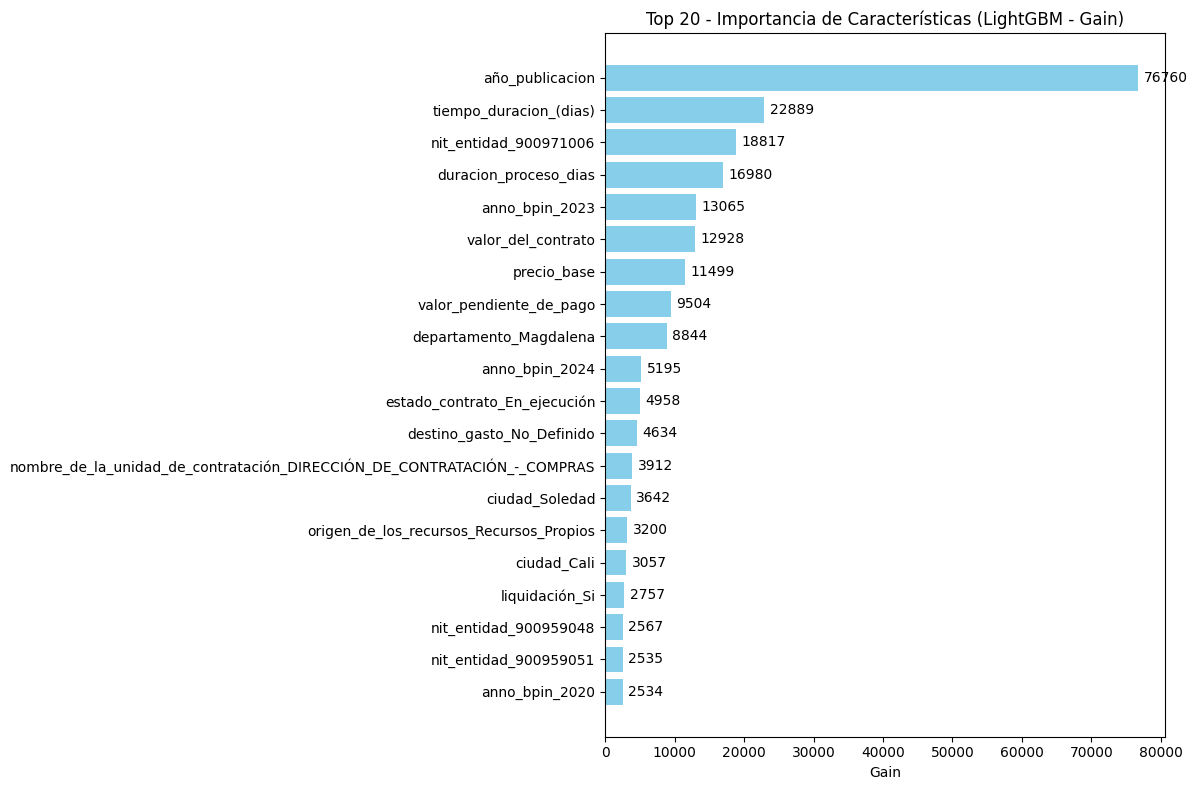

In [46]:
# Obtener importancia por 'gain'
booster_lgb = model_LGB.booster_
importancias_gain = booster_lgb.feature_importance(importance_type='gain')
features = booster_lgb.feature_name()

# Crear DataFrame
importancia_gain_df = pd.DataFrame({
    'Feature': features,
    'Importance': importancias_gain
}).sort_values(by='Importance', ascending=False).head(20)

# Gráfico de barras horizontal con valores
plt.figure(figsize=(12, 8))
bars = plt.barh(importancia_gain_df['Feature'][::-1], importancia_gain_df['Importance'][::-1], color='skyblue')
plt.xlabel('Gain')
plt.title('Top 20 - Importancia de Características (LightGBM - Gain)')

# Añadir los valores numéricos a cada barra
for bar in bars:
    width = bar.get_width()
    plt.text(width + max(importancia_gain_df['Importance']) * 0.01,
             bar.get_y() + bar.get_height() / 2,
             f'{int(width)}',
             va='center')

plt.tight_layout()
plt.show()


## Redes neuronales

In [47]:
# Escalar los datos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


### Salario medio

c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


995/995 ━━━━━━━━━━━━━━━━━━━━ 1s 512us/step


c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


995/995 ━━━━━━━━━━━━━━━━━━━━ 1s 679us/step


c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


...

995/995 ━━━━━━━━━━━━━━━━━━━━ 1s 901us/step


c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


995/995 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


995/995 ━━━━━━━━━━━━━━━━━━━━ 1s 972us/step


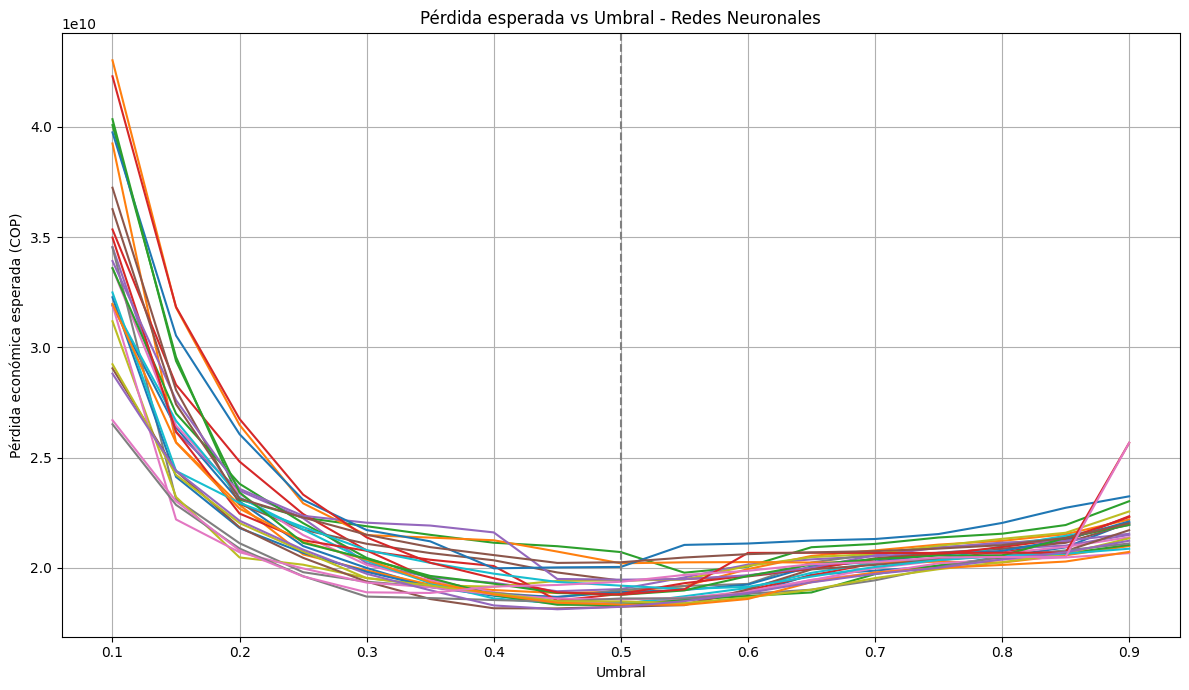

In [ ]:

# Hiperparámetros a combinar
n_neurons_1_list = [32, 64,128]
n_neurons_2_list = [16, 32,64]
learning_rates = [0.001, 0.005,0.01]
epochs = 50
batch_size = 64
umbrales = np.arange(0.1, 0.95, 0.05)

# Costos
costo_FN = veinte_por_ciento
costo_FP = salario_equipo_revision_medio

# Guardar resultados
resultados_nn = {}

# Combinaciones
combinaciones = list(product(n_neurons_1_list, n_neurons_2_list, learning_rates))

for n1, n2, lr in combinaciones:
    model = Sequential([
        Dense(n1, activation='relu', input_shape=(X_train_scaled.shape[1],)),
        Dense(n1, activation='relu'),
        Dense(n2, activation='relu'),
        Dense(n2, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    
    model.compile(optimizer=Adam(learning_rate=lr),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    
    model.fit(X_train_scaled, y_train,
              validation_data=(X_test_scaled, y_test),
              epochs=epochs,
              batch_size=batch_size,
              verbose=0)
    
    y_proba = model.predict(X_test_scaled)
    perdidas = []
    
    for umbral in umbrales:
        y_pred = (y_proba >= umbral).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
        perdida = (fn * costo_FN) + (fp * costo_FP)
        perdidas.append(perdida)

    nombre = f"NN n1={n1}, n2={n2}, lr={lr}"
    resultados_nn[nombre] = perdidas

# Graficar pérdidas
plt.figure(figsize=(12, 7))
for nombre, perdidas in resultados_nn.items():
    plt.plot(umbrales, perdidas, label=nombre)

plt.axvline(x=0.5, color='gray', linestyle='--', label='Umbral 0.5')
plt.title("Pérdida esperada vs Umbral - Redes Neuronales")
plt.xlabel("Umbral")
plt.ylabel("Pérdida económica esperada (COP)")
plt.grid(True)
plt.tight_layout()
plt.show()


In [14]:
# Inicializar variables
mejor_combinacion_nn = None
mejor_umbral_nn = None
mejor_perdida_nn = float('inf')

peor_combinacion_nn = None
peor_umbral_nn = None
peor_perdida_nn = float('-inf')

# Evaluar todas las combinaciones
for nombre, perdidas in resultados_nn.items():
    idx_min = np.argmin(perdidas)
    min_perdida = perdidas[idx_min]

    idx_max = np.argmax(perdidas)
    max_perdida = perdidas[idx_max]

    if min_perdida < mejor_perdida_nn:
        mejor_perdida_nn = min_perdida
        mejor_combinacion_nn = nombre
        mejor_umbral_nn = umbrales[idx_min]

    if max_perdida > peor_perdida_nn:
        peor_perdida_nn = max_perdida
        peor_combinacion_nn = nombre
        peor_umbral_nn = umbrales[idx_max]

# Calcular promedio de pérdidas por umbral
promedio_por_umbral_nn = np.mean(np.array(list(resultados_nn.values())), axis=0)
idx_mejor_promedio_nn = np.argmin(promedio_por_umbral_nn)
mejor_umbral_promedio_nn = umbrales[idx_mejor_promedio_nn]
mejor_perdida_promedio_nn = promedio_por_umbral_nn[idx_mejor_promedio_nn]

# Mostrar resultados
print("Mejor combinación (Red Neuronal):")
print(f"Parámetros: {mejor_combinacion_nn}")
print(f"Umbral óptimo: {mejor_umbral_nn:.2f}")
print(f"Pérdida mínima: ${mejor_perdida_nn:,.0f} COP\n")

print("Peor combinación (Red Neuronal):")
print(f"Parámetros: {peor_combinacion_nn}")
print(f"Umbral más costoso: {peor_umbral_nn:.2f}")
print(f"Pérdida máxima: ${peor_perdida_nn:,.0f} COP\n")

print("Promedio de combinaciones (Red Neuronal):")
print(f"Umbral óptimo promedio: {mejor_umbral_promedio_nn:.2f}")
print(f"Pérdida mínima promedio: ${mejor_perdida_promedio_nn:,.0f} COP")

Mejor combinación (Red Neuronal):
Parámetros: NN n1=32, n2=64, lr=0.001
Umbral óptimo: 0.45
Pérdida mínima: $18,071,673,211 COP

Peor combinación (Red Neuronal):
Parámetros: NN n1=64, n2=32, lr=0.01
Umbral más costoso: 0.10
Pérdida máxima: $44,904,868,303 COP

Promedio de combinaciones (Red Neuronal):
Umbral óptimo promedio: 0.50
Pérdida mínima promedio: $18,884,621,154 COP


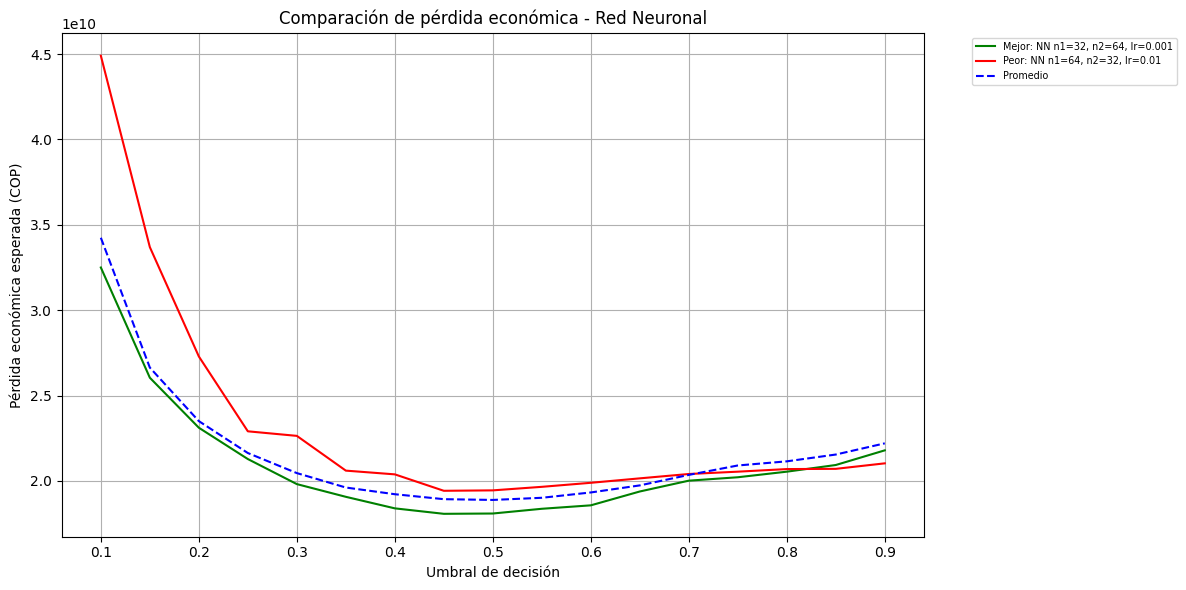

In [15]:
# Verificación de longitudes
if not (len(umbrales) == len(resultados_nn[mejor_combinacion_nn]) == len(resultados_nn[peor_combinacion_nn]) == len(promedio_por_umbral_nn)):
    raise ValueError("Las longitudes no coinciden entre umbrales y resultados_nn.")

# Graficar
plt.figure(figsize=(12, 6))

# Mejor
plt.plot(umbrales, resultados_nn[mejor_combinacion_nn], 'g-', label=f"Mejor: {mejor_combinacion_nn}")

# Peor
plt.plot(umbrales, resultados_nn[peor_combinacion_nn], 'r-', label=f"Peor: {peor_combinacion_nn}")

# Promedio
plt.plot(umbrales, promedio_por_umbral_nn, 'b--', label="Promedio")

# Estética
plt.title("Comparación de pérdida económica - Red Neuronal")
plt.xlabel("Umbral de decisión")
plt.ylabel("Pérdida económica esperada (COP)")
plt.legend(fontsize='x-small', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()


In [48]:
# Parámetros
n1 = 32
n2 = 64
learning_rate = 0.001
epochs = 50
batch_size = 64
umbral_nn = 0.45  # Umbral para clasificación

# Crear el modelo
model_nn = Sequential([
    Dense(n1, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(n1, activation='relu'),
    Dense(n2, activation='relu'),
    Dense(n2, activation='relu'),
    Dense(1, activation='sigmoid')  # Salida binaria
])

# Compilar el modelo
model_nn.compile(optimizer=Adam(learning_rate=learning_rate),
                 loss='binary_crossentropy',
                 metrics=['accuracy'])

# Entrenar el modelo
history = model_nn.fit(X_train_scaled, y_train,
                       validation_data=(X_test_scaled, y_test),
                       epochs=epochs,
                       batch_size=batch_size,
                       verbose=1)

# Evaluar el modelo
loss, accuracy = model_nn.evaluate(X_test_scaled, y_test)
print(f"Loss: {loss}, Accuracy: {accuracy}")

# Predecir probabilidades
y_proba_nn = model_nn.predict(X_test_scaled)

# Aplicar el umbral personalizado
y_pred_nn_custom = (y_proba_nn >= umbral_nn).astype(int)

# Evaluación
print(f"\nEvaluación del modelo de red neuronal con umbral = {umbral_nn}\n")
print("Reporte de clasificación:")
print(classification_report(y_test, y_pred_nn_custom, target_names=['No Adición', 'Adición']))

# Matriz de confusión
conf_matrix_nn = confusion_matrix(y_test, y_pred_nn_custom)
print("\nMatriz de confusión:")
print(conf_matrix_nn)

# Calcular pérdida económica total
costo_FN = veinte_por_ciento    # Dejar pasar una adición real
costo_FP = salario_equipo_revision_medio               # Revisar innecesariamente un contrato
tn_nn, fp_nn, fn_nn, tp_nn = conf_matrix_nn.ravel()
perdida_total_nn = (fn_nn * costo_FN) + (fp_nn * costo_FP)

# Mostrar resultado
print(f"\nCosto total estimado con umbral = {umbral_nn}: ${perdida_total_nn:,.0f} COP")

c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
1990/1990 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8965 - loss: 0.2917 - val_accuracy: 0.9092 - val_loss: 0.2524
Epoch 2/50
1990/1990 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9074 - loss: 0.2513 - val_accuracy: 0.9103 - val_loss: 0.2431
Epoch 3/50
1990/1990 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9088 - loss: 0.2441 - val_accuracy: 0.9123 - val_loss: 0.2413
Epoch 4/50
1990/1990 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9113 - loss: 0.2363 - val_accuracy: 0.9127 - val_loss: 0.2398
Epoch 5/50
1990/1990 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9129 - loss: 0.2315 - val_accuracy: 0.9138 - val_loss: 0.2355
Epoch 6/50
1990/1990 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9123 - loss: 0.2297 - val_accuracy: 0.9120 - val_loss: 0.2359
Epoch 7/50
1990/1990 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9149 - loss: 0.2257 - val_accuracy: 0.9129 - val_loss: 0.2360
Epoch 8/50
1990/1990 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9152 - loss: 0.2233 - 

In [49]:
Costoporcontratonn=perdida_total_nn/len(X_test)
Costoporcontratonn

578274.3805683735

In [50]:
# Rango de umbrales a evaluar
umbrales = np.arange(0.05, 0.95, 0.01)

costos_nn = []
cambios_nn = [0]
fn_list_nn = []
fp_list_nn = []

# Evaluar cada umbral
for umbral in umbrales:
    y_pred = (y_proba_nn >= umbral).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    costo = (fn * costo_FN) + (fp * costo_FP)
    costos_nn.append(costo)
    fn_list_nn.append(fn)
    fp_list_nn.append(fp)

# Cambios porcentuales
for i in range(1, len(costos_nn)):
    cambio = (costos_nn[i] - costos_nn[i-1]) / costos_nn[i-1] * 100
    cambios_nn.append(cambio)

# Crear tabla
tabla_sensibilidad_nn = pd.DataFrame({
    'Umbral': umbrales,
    'Costo Total': costos_nn,
    'Cambio % vs anterior': cambios_nn,
    'FN': fn_list_nn,
    'FP': fp_list_nn
})

pd.set_option('display.float_format', '{:,.2f}'.format)
display(tabla_sensibilidad_nn.head(10))  # O .tail(), o todo

# Sensibilidad media (absoluta)
sensibilidad_media_nn = np.mean(np.abs(tabla_sensibilidad_nn['Cambio % vs anterior'][1:]))  # sin el primero
print(f"Sensibilidad media: {sensibilidad_media_nn:.2f}% por cada 1% de cambio en el umbral")



,Umbral,Costo Total,Cambio % vs anterior,FN,FP
0,0.05,"48,257,650,188.14",0.00,568,8253
1,0.06,"43,302,700,741.40",-10.27,624,7248
2,0.07,"39,734,015,120.91",-8.24,700,6475
3,0.08,"36,762,279,492.16",-7.48,749,5851
4,0.09,"34,578,198,471.03",-5.94,794,5380
5,0.10,"32,107,904,996.51",-7.14,848,4843
6,0.11,"30,608,711,719.62",-4.67,891,4503
7,0.12,"29,107,340,734.97",-4.91,925,4175
8,0.13,"27,439,271,738.52",-5.73,969,3802
9,0.14,"26,398,070,244.95",-3.79,1014,3545


Sensibilidad media: 1.32% por cada 1% de cambio en el umbral


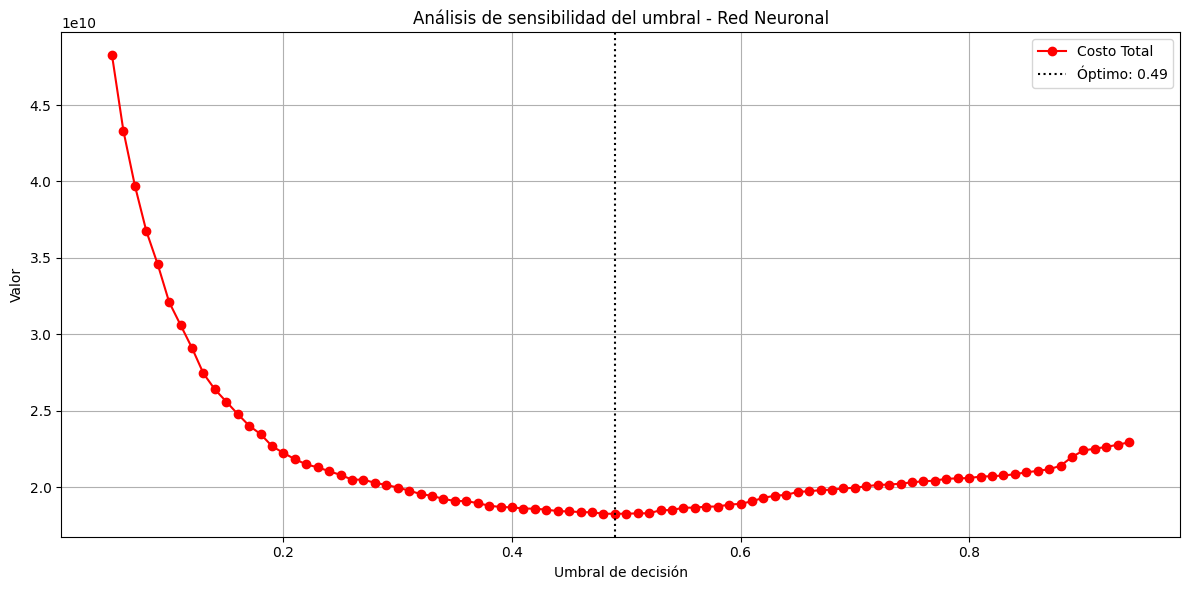

In [51]:
# Encontrar umbral óptimo
idx_min_nn = np.argmin(costos_nn)
mejor_umbral_nn = umbrales[idx_min_nn]
mejor_costo_nn = costos_nn[idx_min_nn]

plt.figure(figsize=(12, 6))

# Costo
plt.plot(umbrales, costos_nn, 'o-r', label='Costo Total')


# Línea de umbral óptimo
plt.axvline(mejor_umbral_nn, color='black', linestyle=':', label=f'Óptimo: {mejor_umbral_nn:.2f}')

plt.title("Análisis de sensibilidad del umbral - Red Neuronal")
plt.xlabel("Umbral de decisión")
plt.ylabel("Valor")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Sensibilidad precio

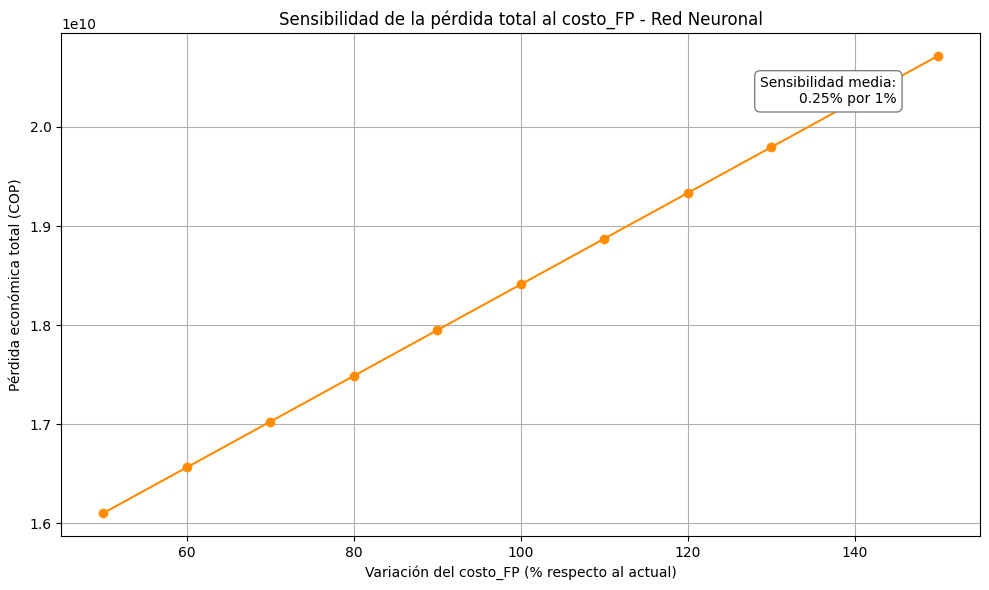

In [52]:
# Porcentajes de variación del costo_FP (de 50% a 150%)
porcentajes = np.array([0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5])
costos_FP = salario_equipo_revision_medio * porcentajes

# Predicciones fijas con umbral ya aplicado
y_pred_nn_custom = (y_proba_nn >= umbral_nn).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_nn_custom).ravel()

# Costo base (para cálculo porcentual)
costo_base = (fn * costo_FN) + (fp * salario_equipo_revision_medio)

# Cálculo de pérdidas absolutas
perdidas = [(fn * costo_FN) + (fp * cfp) for cfp in costos_FP]

# Pérdidas en porcentaje respecto al valor base
perdidas_pct = [(p / costo_base - 1) * 100 for p in perdidas]

# Calcular sensibilidad media (% de cambio en pérdida total por 1% en costo_FP)
delta_y = np.gradient(perdidas_pct, porcentajes * 100)
sensibilidad_media_pct = np.mean(delta_y)

# Graficar
plt.figure(figsize=(10, 6))
plt.plot(porcentajes * 100, perdidas, marker='o', color='darkorange')
plt.title("Sensibilidad de la pérdida total al costo_FP - Red Neuronal")
plt.xlabel("Variación del costo_FP (% respecto al actual)")
plt.ylabel("Pérdida económica total (COP)")
plt.grid(True)

# Mostrar sensibilidad como porcentaje en una esquina
plt.text(
    145, perdidas[-1] * 0.99,
    f"Sensibilidad media:\n{sensibilidad_media_pct:.2f}% por 1%",
    fontsize=10,
    ha='right',
    va='top',
    bbox=dict(boxstyle="round,pad=0.4", facecolor='white', edgecolor='gray')
)

plt.tight_layout()
plt.show()


Importancia caracteristicas shap

c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\shap\explainers\_deep\deep_tf.py:94: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn(
c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\models\functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=['Tensor(shape=(100, 304))']
  warnings.warn(msg)
c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\models\functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=['Tensor(shape=(200, 304))']
  warnings.warn(msg)
c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\models\functional.py:238: UserWarning: The structure of `in

<Figure size 640x480 with 0 Axes>

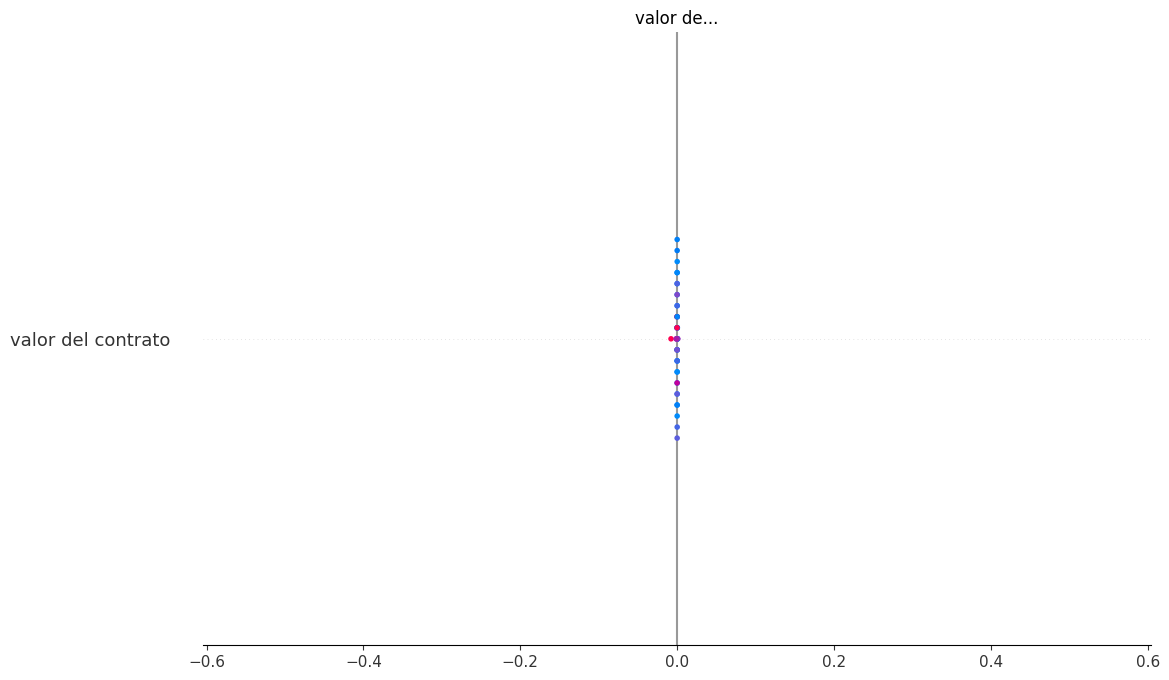

In [53]:
# Seleccionar una muestra pequeña para el análisis SHAP (por rendimiento)
background = X_train_scaled[np.random.choice(X_train_scaled.shape[0], 100, replace=False)]
sample_X = X_test_scaled[np.random.choice(X_test_scaled.shape[0], 50, replace=False)]

# Crear el DeepExplainer
explainer_nn = shap.DeepExplainer(model_nn, background)

# Calcular los valores SHAP
shap_values_nn = explainer_nn.shap_values(sample_X)

# Plot resumen
shap.summary_plot(shap_values_nn, sample_X, feature_names=X_train.columns)


PermutationExplainer explainer: 31837it [29:20, 18.08it/s]                           
C:\Users\user\AppData\Local\Temp\ipykernel_12888\2465327732.py:3: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test)
c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\shap\plots\_beeswarm.py:1153: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  pl.tight_layout()


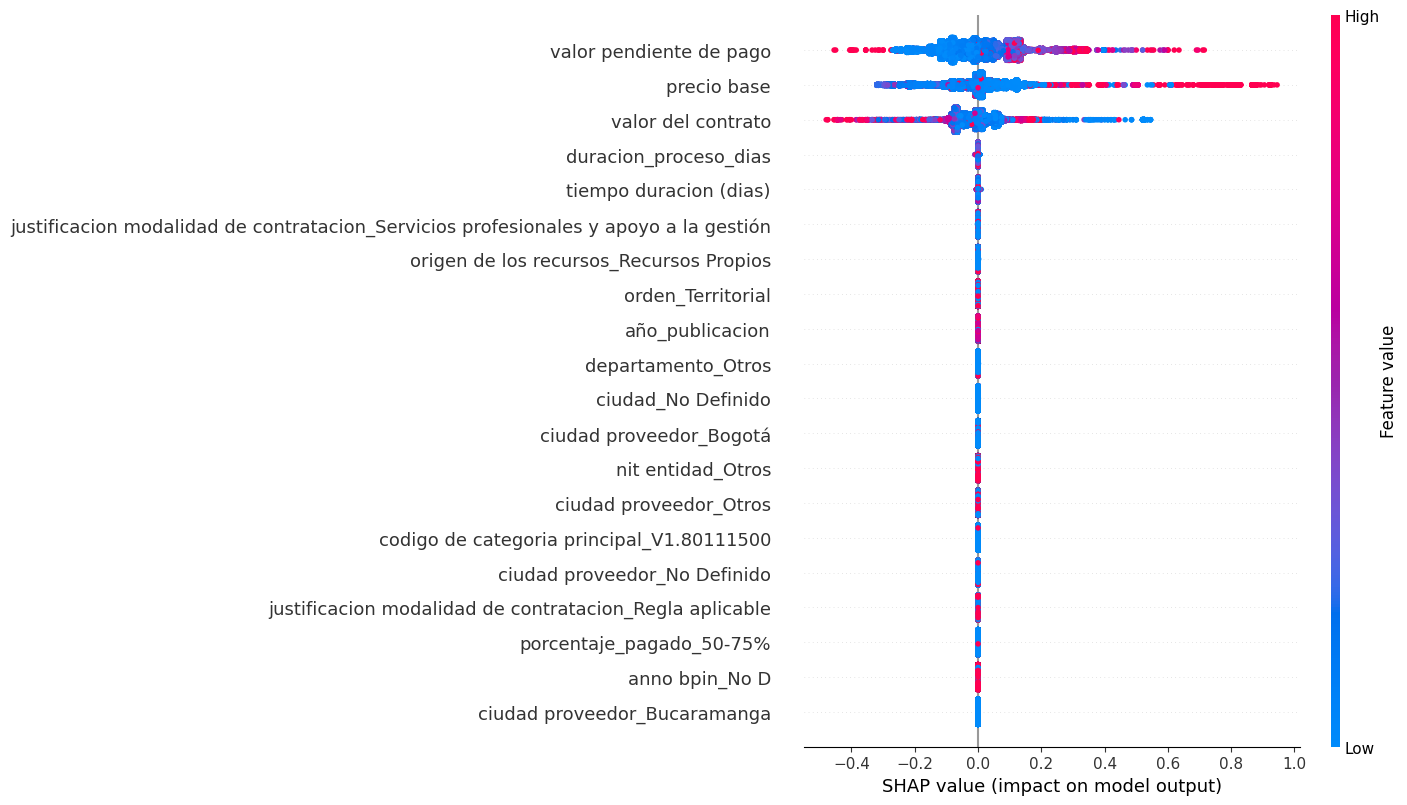

In [54]:
explainer = shap.Explainer(model_nn, X_train[:100])
shap_values = explainer(X_test)
shap.summary_plot(shap_values, X_test)

C:\Users\user\AppData\Local\Temp\ipykernel_12888\635351054.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, plot_type="bar", title="Importancia de características - Red Neuronal")
c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\shap\plots\_beeswarm.py:1153: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  pl.tight_layout()


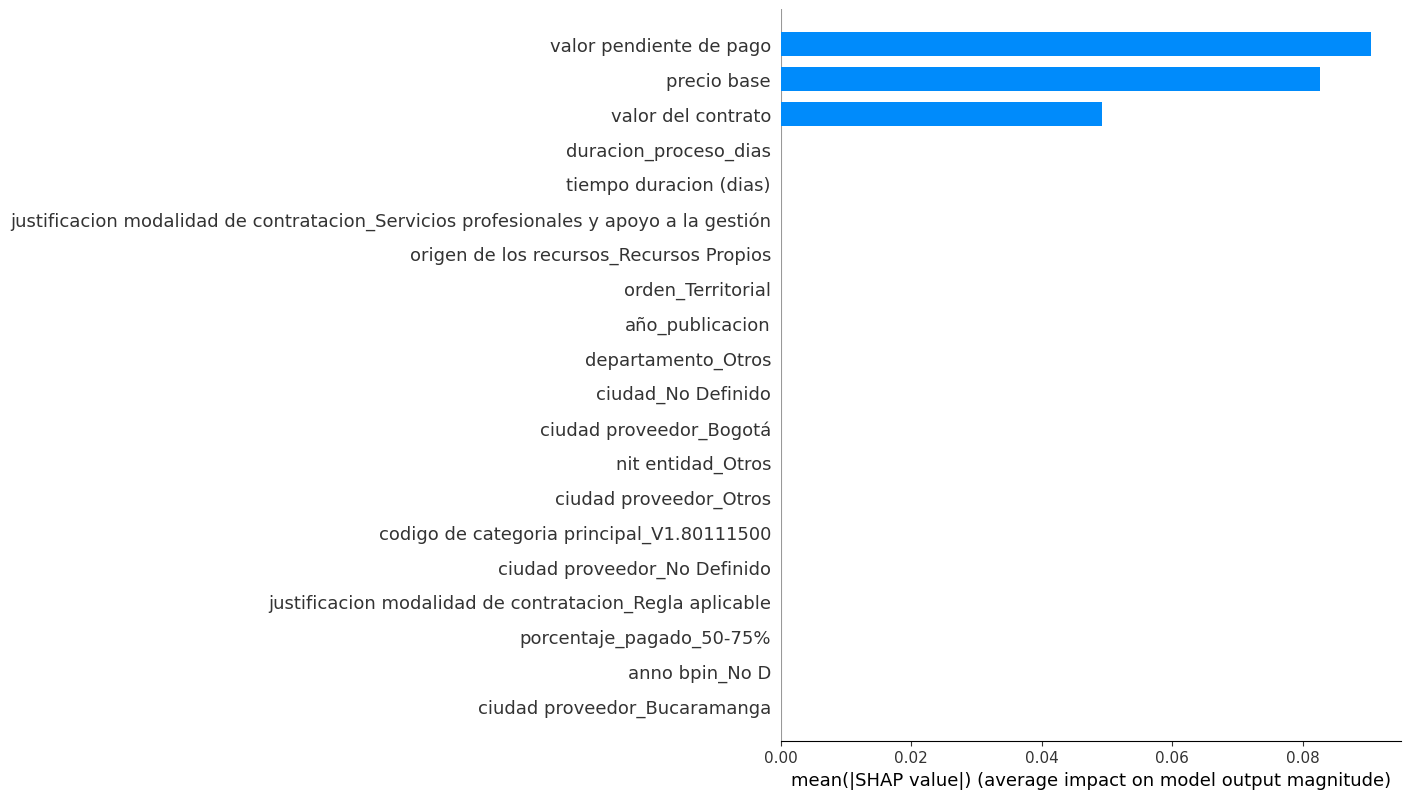

In [55]:
shap.summary_plot(shap_values, X_test, plot_type="bar", title="Importancia de características - Red Neuronal")
